In [1]:
import os
import sys

sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from utils.datasets import GCDataset, Dataset, HGCDataset
from agents.gcivl.state.dual import GCIVLDualAgent, get_config as get_config_dual
from agents.gcivl.original import GCIVLAgent, get_config
from utils.flax_utils import restore_agent
import ogbench

env_medium, train_dataset_medium, val_dataset_medium = ogbench.make_env_and_datasets(
    dataset_name="antmaze-medium-navigate-v0"
)
env_large, train_dataset_large, val_dataset_large = ogbench.make_env_and_datasets(
    dataset_name="antmaze-large-navigate-v0"
)
agent_config = get_config()
agent_config_dual = get_config_dual()

train_dataset_med = GCDataset(
    Dataset.create(norm=False, **train_dataset_medium), agent_config
)
train_dataset_large = GCDataset(
    Dataset.create(norm=False, **train_dataset_large), agent_config
)

example_batch_med = train_dataset_med.sample(1)
example_batch_large = train_dataset_large.sample(1)

agent_gcivl = GCIVLAgent.create(
    0,
    example_batch_med["observations"],
    example_batch_med["actions"],
    agent_config,
    ex_goals=None,
)
agent_gcivl_dual = GCIVLDualAgent.create(
    0,
    example_batch_med["observations"],
    example_batch_med["actions"],
    agent_config_dual,
    ex_goals=None,
)
print(env_large.unwrapped.task_infos)

[{'task_name': 'task1', 'init_ij': (1, 1), 'init_xy': (0.0, 0.0), 'goal_ij': (7, 10), 'goal_xy': (36.0, 24.0)}, {'task_name': 'task2', 'init_ij': (5, 4), 'init_xy': (12.0, 16.0), 'goal_ij': (7, 1), 'goal_xy': (0.0, 24.0)}, {'task_name': 'task3', 'init_ij': (7, 4), 'init_xy': (12.0, 24.0), 'goal_ij': (1, 10), 'goal_xy': (36.0, 0.0)}, {'task_name': 'task4', 'init_ij': (3, 8), 'init_xy': (28.0, 8.0), 'goal_ij': (5, 4), 'goal_xy': (12.0, 16.0)}, {'task_name': 'task5', 'init_ij': (1, 1), 'init_xy': (0.0, 0.0), 'goal_ij': (5, 4), 'goal_xy': (12.0, 16.0)}]


In [3]:
agent_gcivl = restore_agent(
    agent_gcivl,
    "../results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints",
    step=1_000_000,
)
agent_gcivl_dual = restore_agent(
    agent_gcivl_dual,
    "../results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints",
    step=1_000_000,
)
agent_gcivl_eikonal = restore_agent(
    agent_gcivl,
    "../results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints",
    step=1_000_000,
)
agent_gcivl_dual_eikonal = restore_agent(
    agent_gcivl_dual,
    "../results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000_eikonal-dual/checkpoints",
    step=1_000_000,
)

Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints


Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000_eikonal-dual/checkpoints


In [4]:
from utils.antmaze_contours import plot_antmaze_learned_and_analytic
from IPython.display import Image, display
import os

samples = train_dataset_large.sample(100)["observations"]


def plot_agent_contours(
    agent, maze_type="medium", obs_dim=None, env=None, save_dir="plots"
):
    """
    Plots and displays learned vs analytic contours for an AntMaze agent.

    Args:
        agent: The pretrained agent (e.g., GCIVLDualAgent).
        maze_type: 'medium' or 'large'.
        obs_dim: Total dimension of the observation (e.g., 29). If None, tries to infer from env or agent.
        env: Optional environment to infer obs_dim from.
        save_dir: Directory to save the resulting plot.
    """
    # 1. Infer obs_dim if not provided
    if obs_dim is None:
        if env is not None:
            obs_dim = env.observation_space.shape[0]
    # 2. Ensure save directory exists
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # 3. Call the plotting utility
    save_path = plot_antmaze_learned_and_analytic(
        agent=agent,
        maze_type=maze_type,
        save_dir=save_dir,
        obs_dim=obs_dim,
        # task_name=f"agent_step_{agent.network.step}",
        goal_xy=(36, 0),
        dataset_samples=samples,
        max_dataset_samples=64,
    )

    # 4. Display in notebook
    display(Image(save_path))
    return save_path

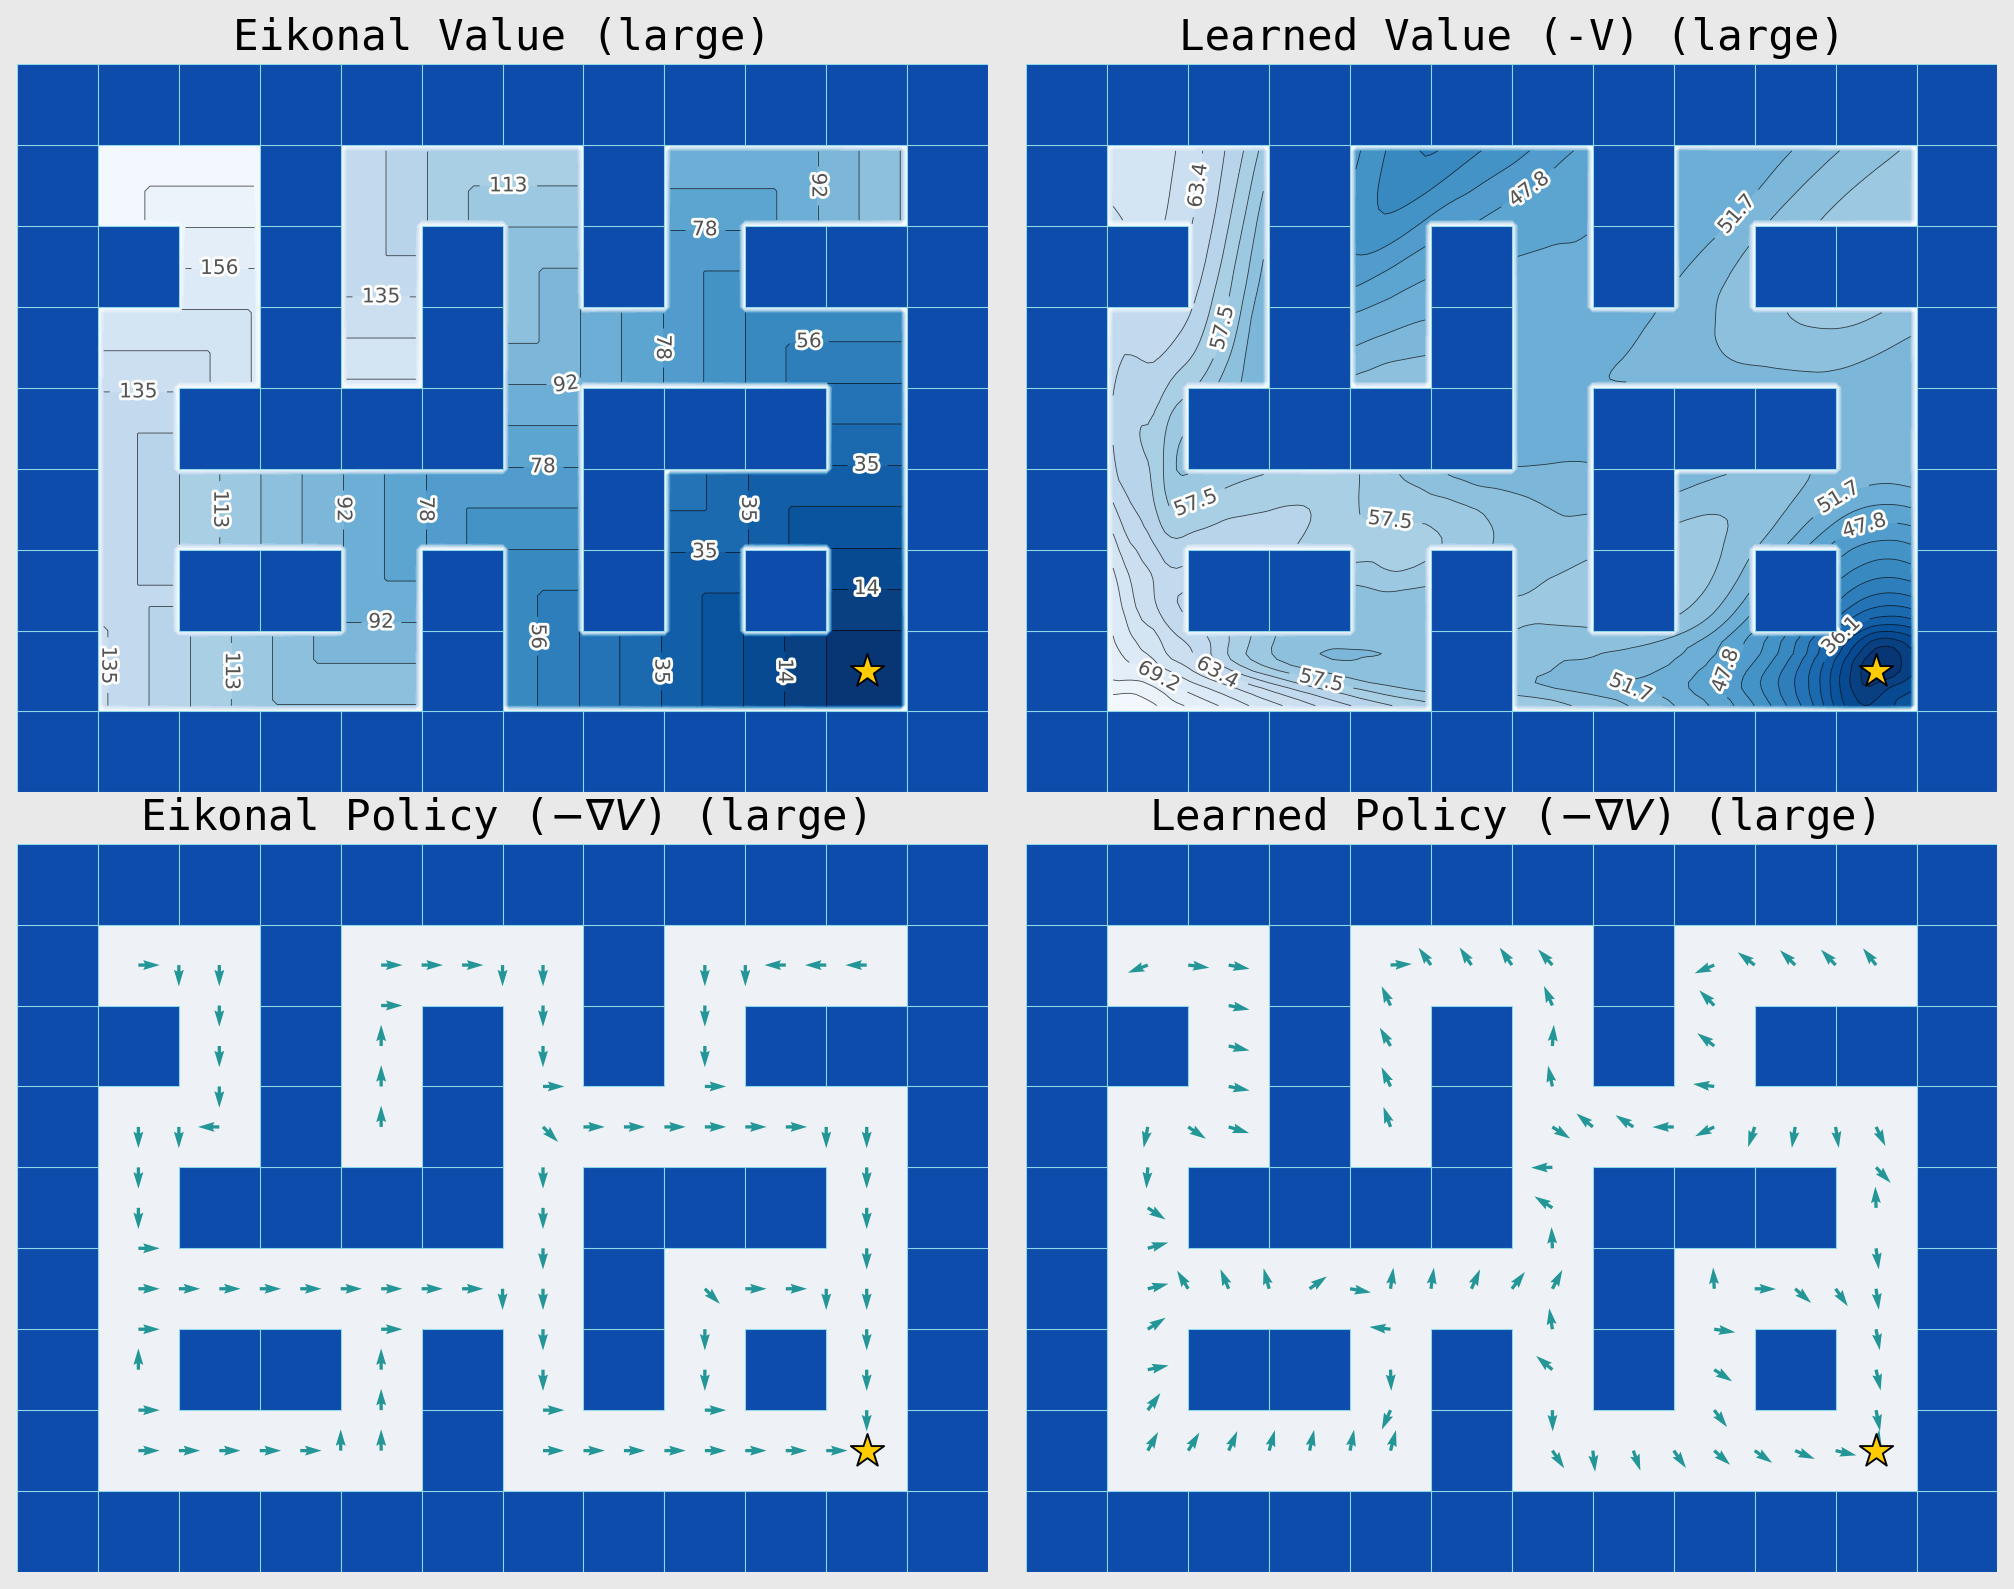

'plots/antmaze_large_learned_analytic_contours.png'

In [5]:
plot_agent_contours(agent_gcivl, maze_type="large", env=env_large)

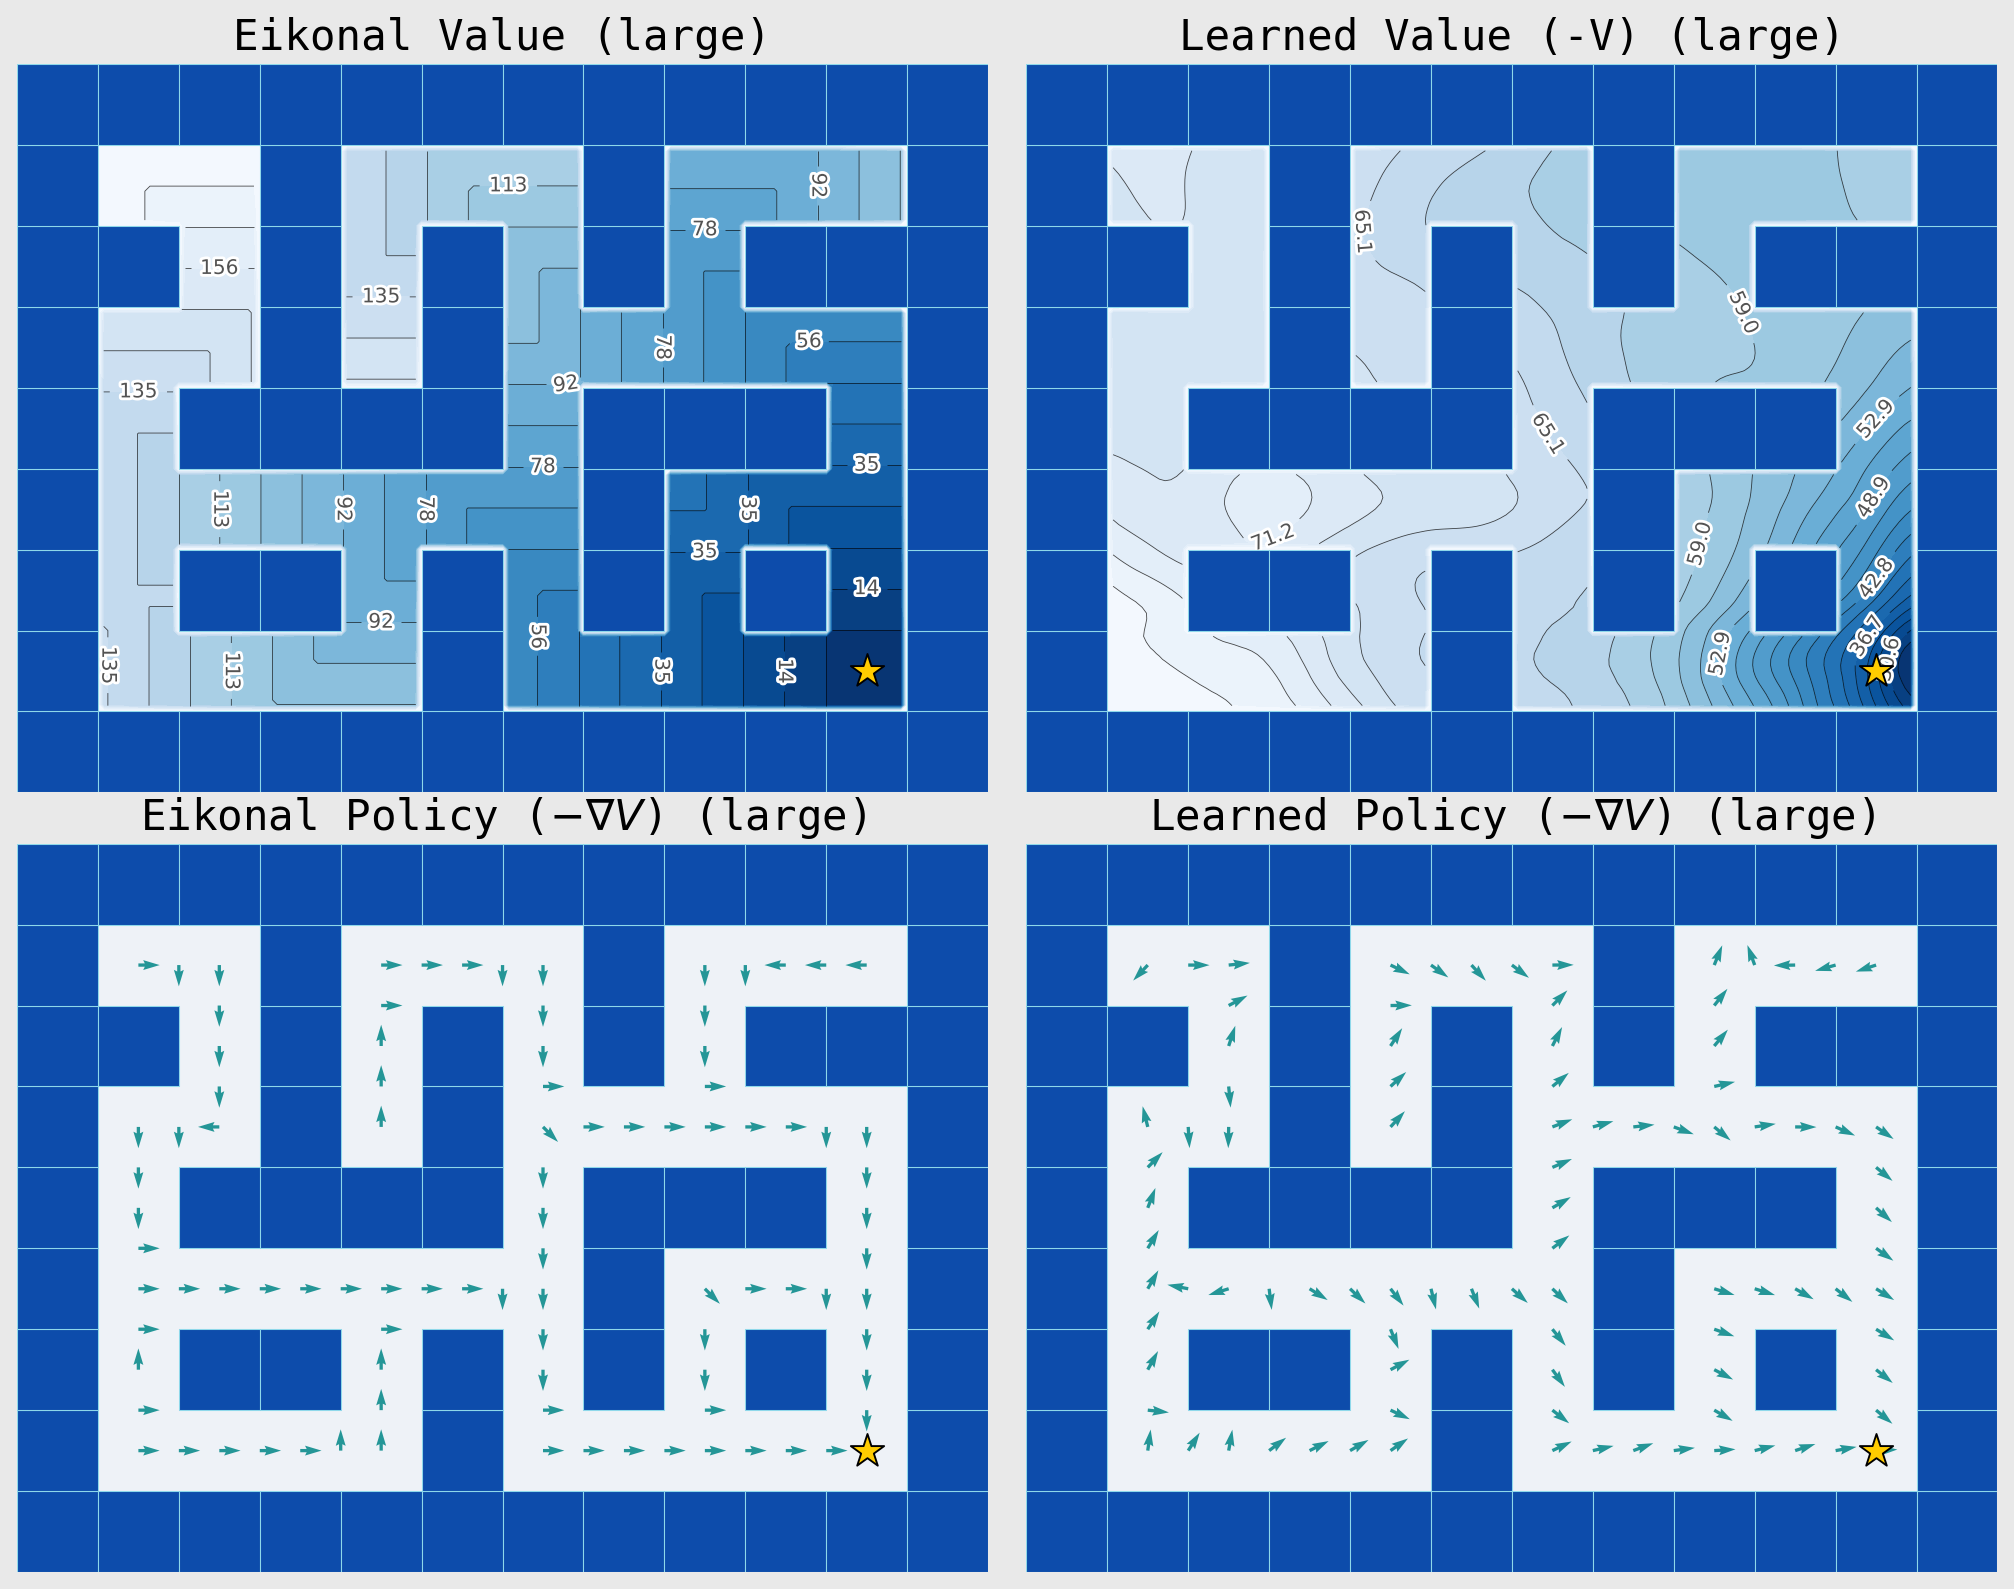

'plots/antmaze_large_learned_analytic_contours.png'

In [6]:
plot_agent_contours(agent_gcivl_dual, maze_type="large", env=env_large)

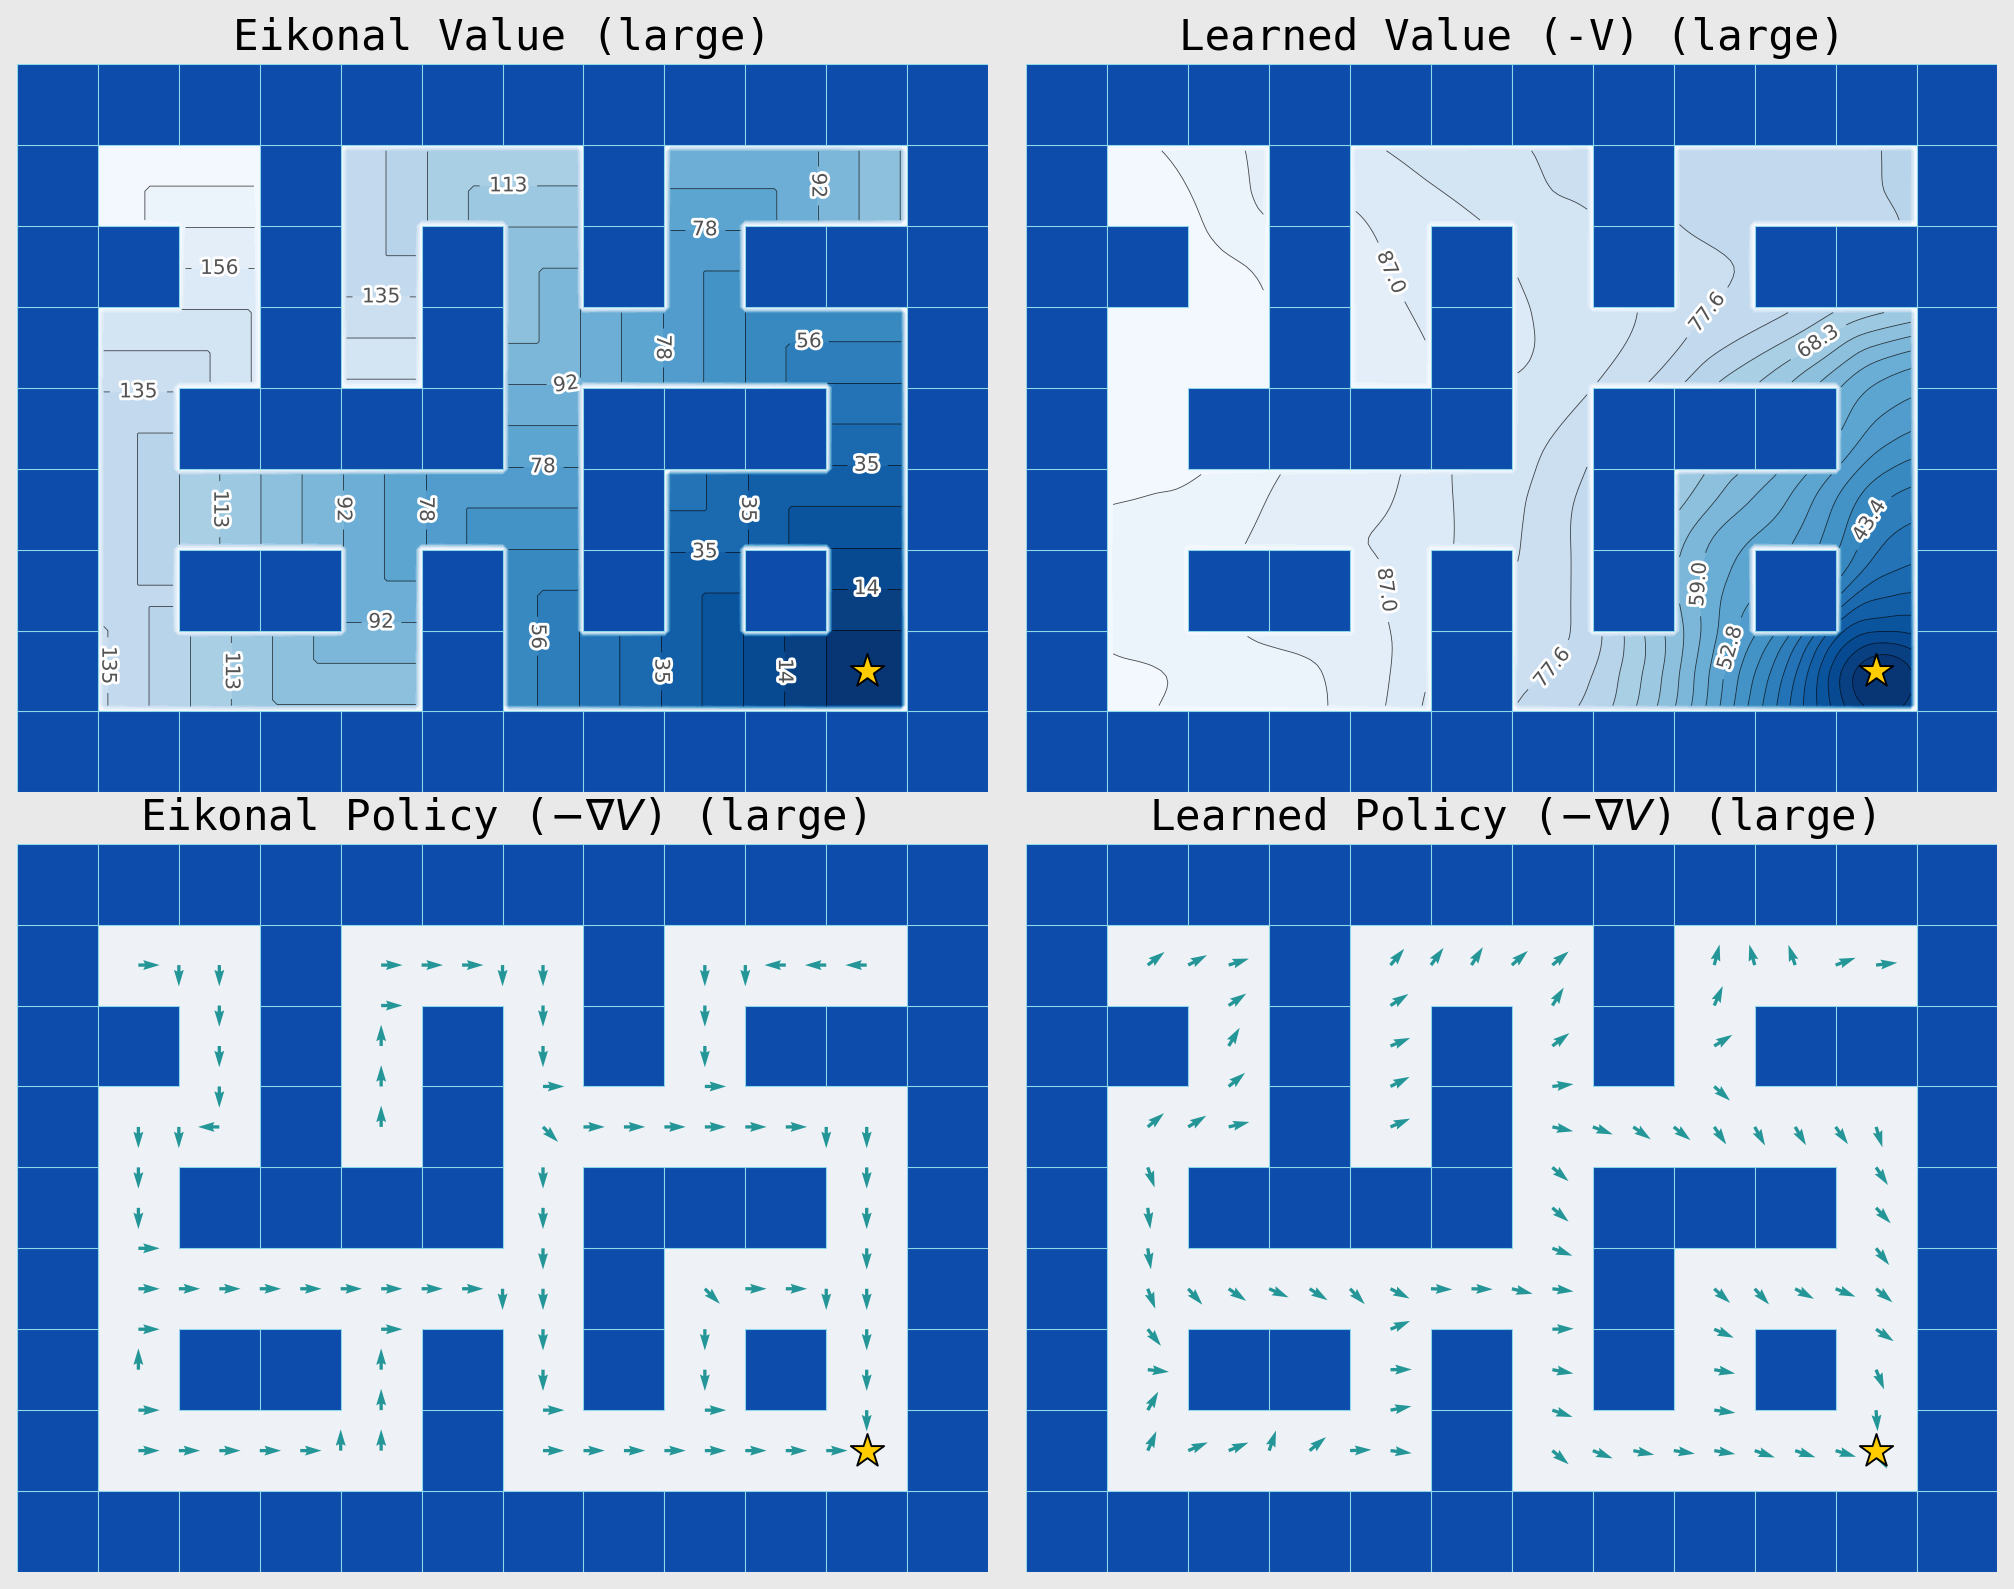

'plots/antmaze_large_learned_analytic_contours.png'

In [7]:
plot_agent_contours(agent_gcivl_eikonal, maze_type="large", env=env_large)

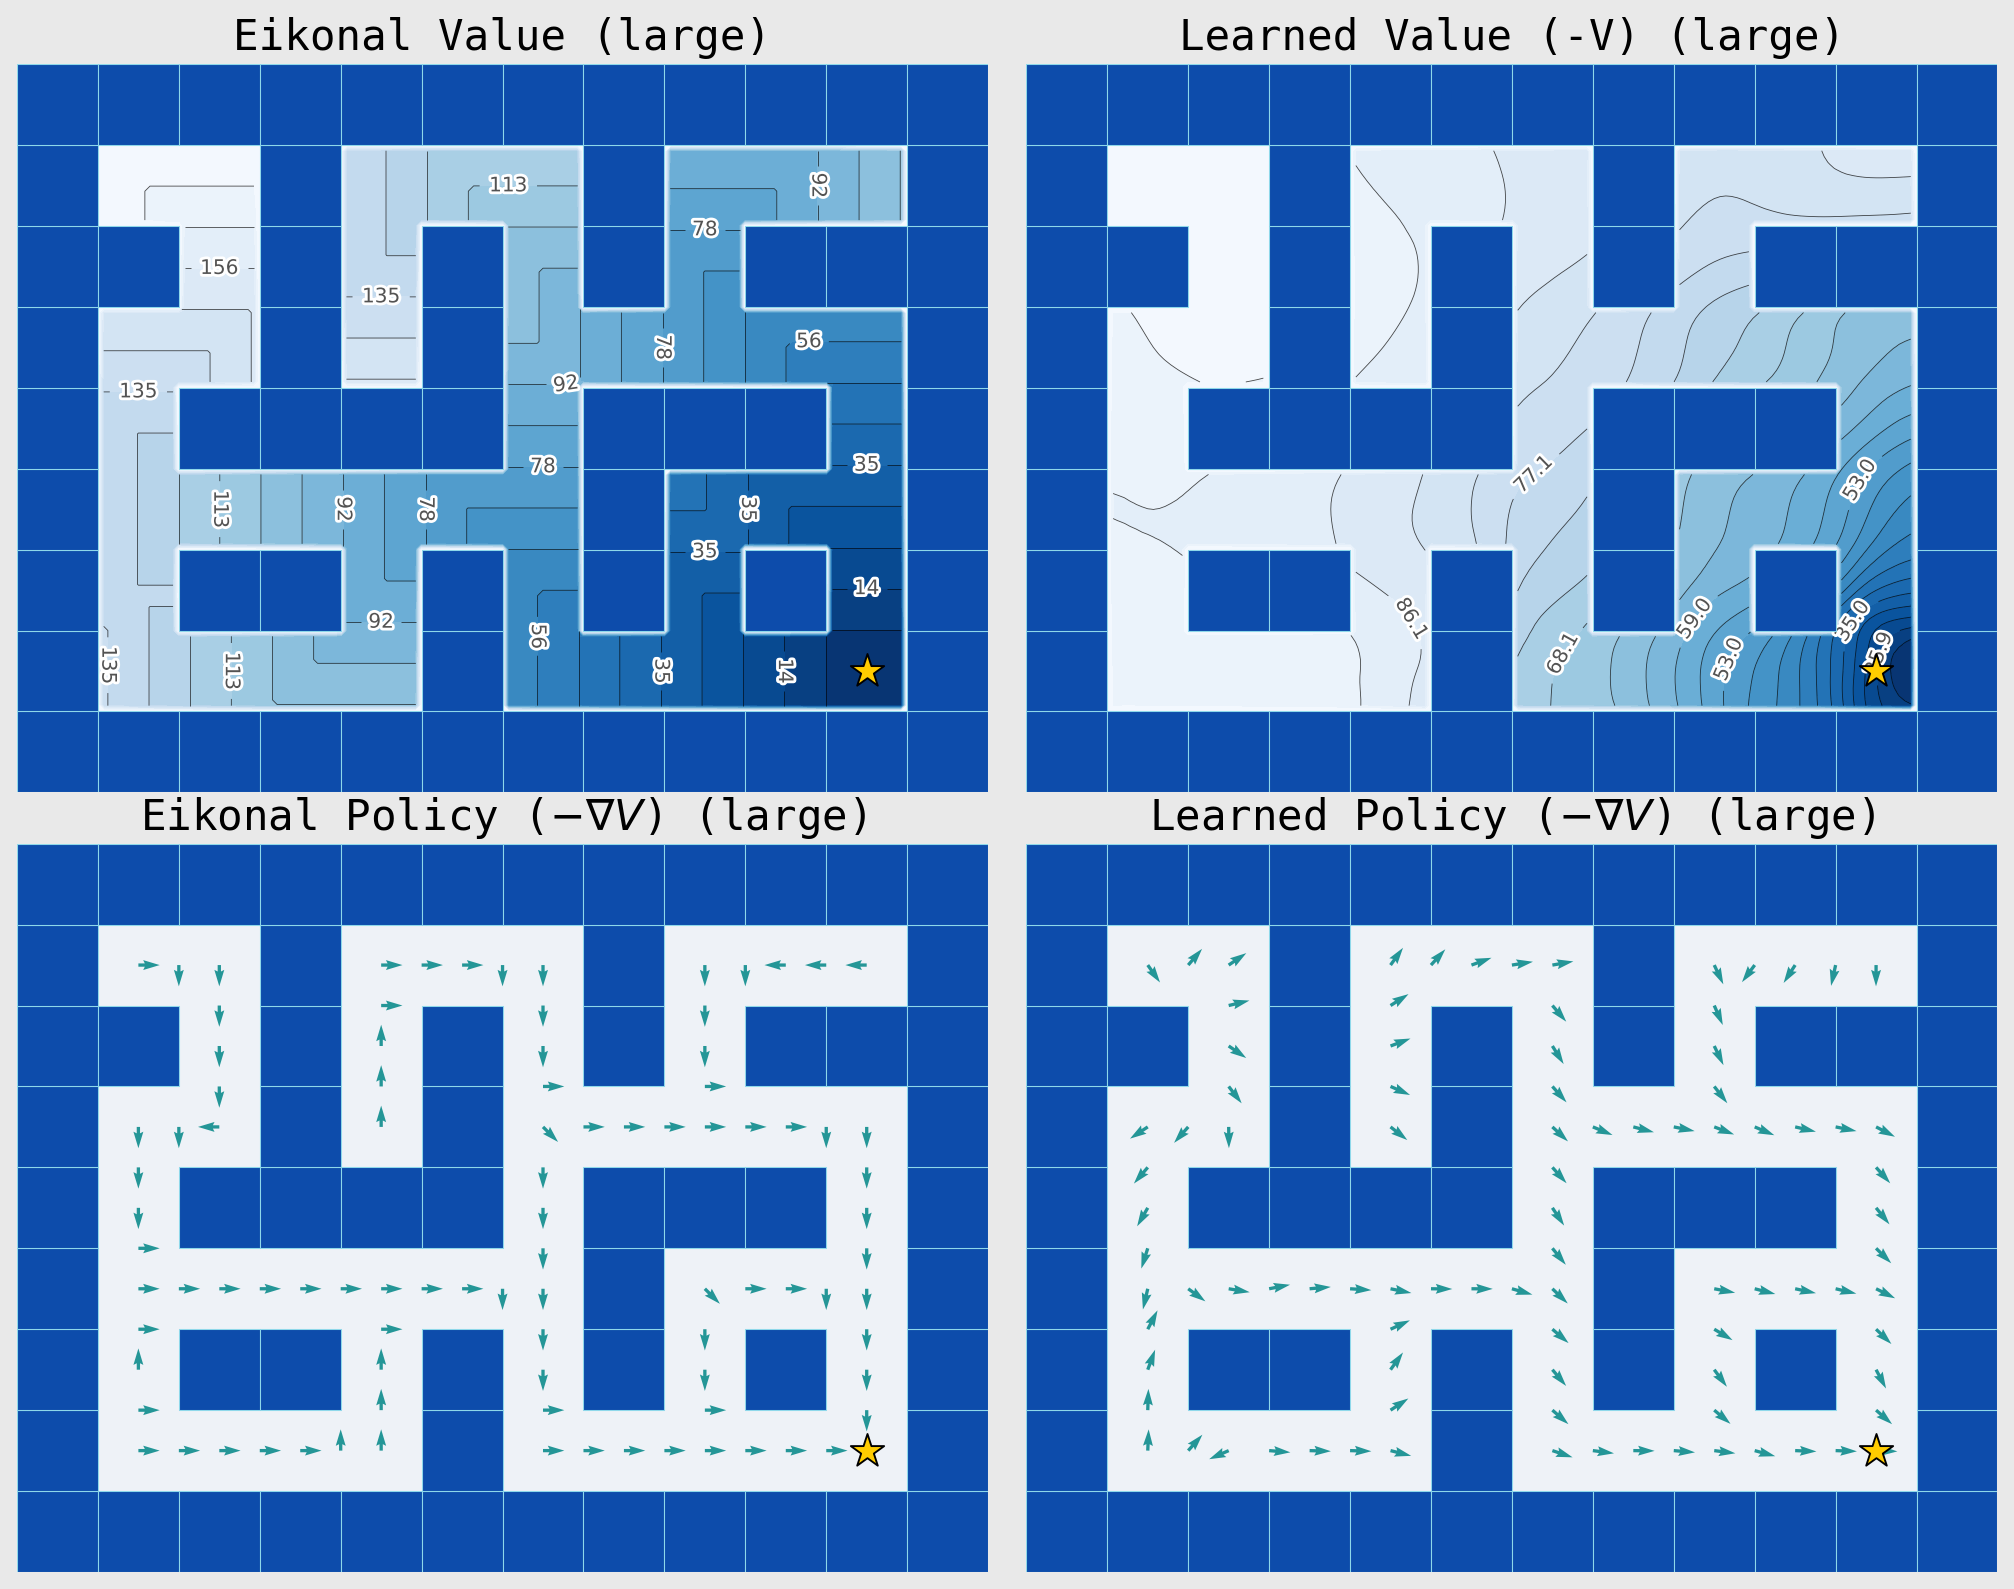

'plots/antmaze_large_learned_analytic_contours.png'

In [8]:
plot_agent_contours(agent_gcivl_dual_eikonal, maze_type="large", env=env_large)

Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/crl/antmaze-large-navigate-v0_crl_sd000_crl-orig-awr/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/crl_dual/antmaze-large-navigate-v0_crl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/daf/antmaze-large-navigate-v0_daf_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gci

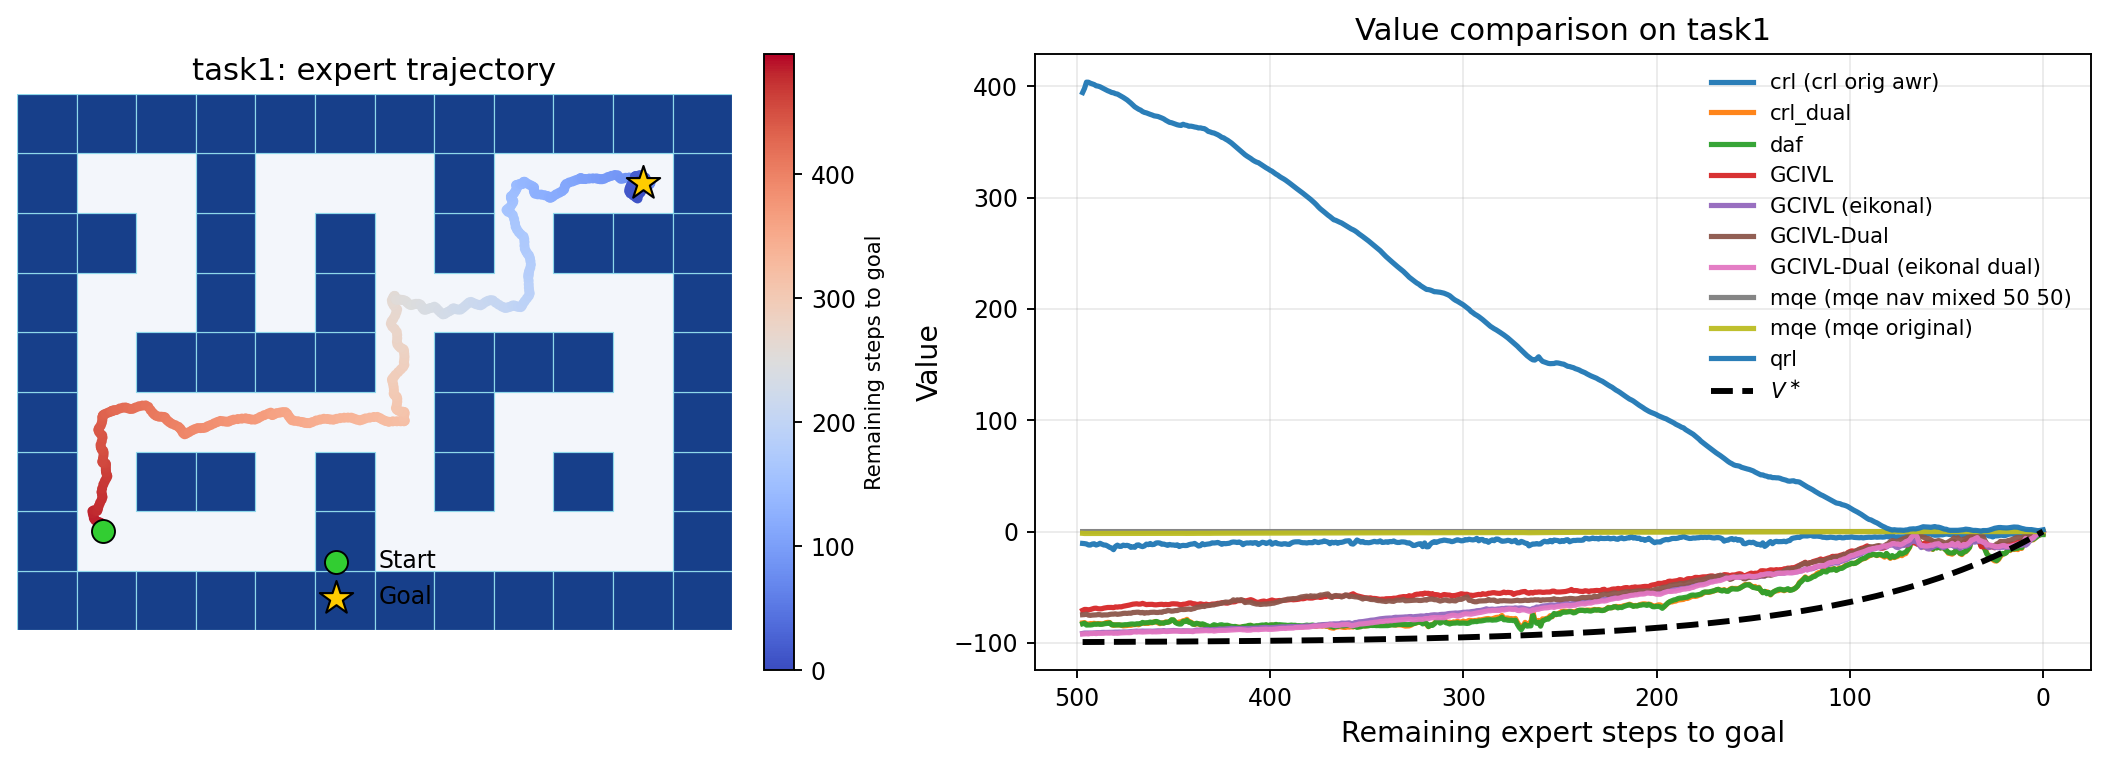

Could not plot ota on task2: Unsupported value extraction for ota


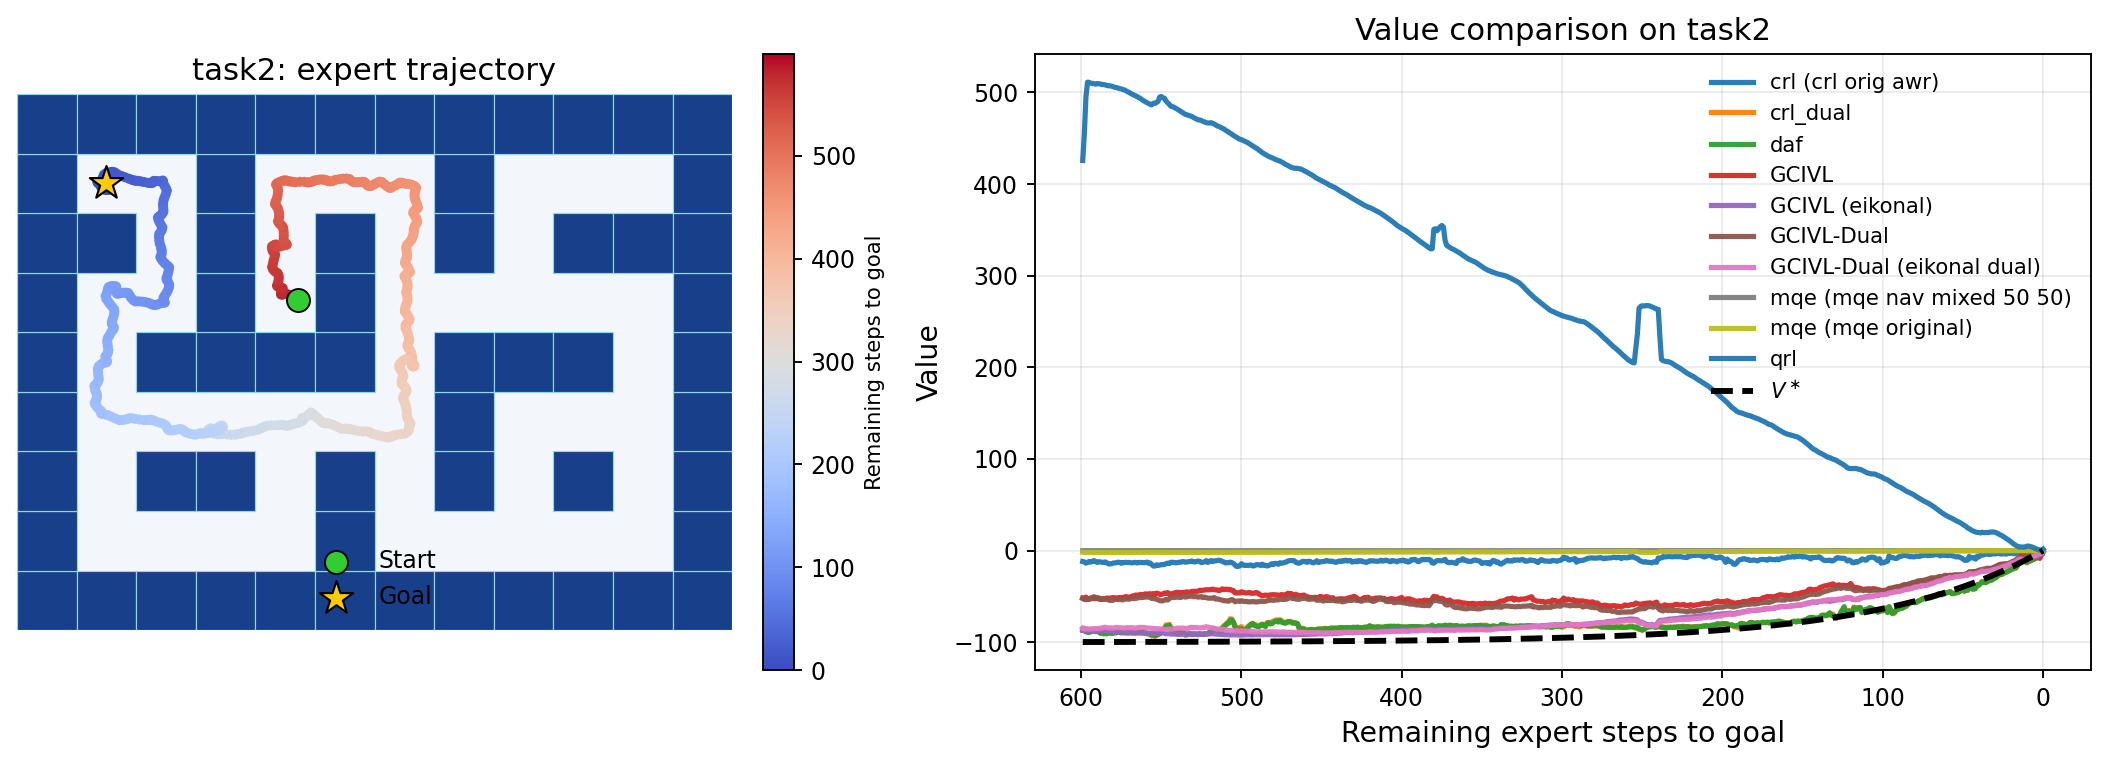

Could not plot ota on task3: Unsupported value extraction for ota


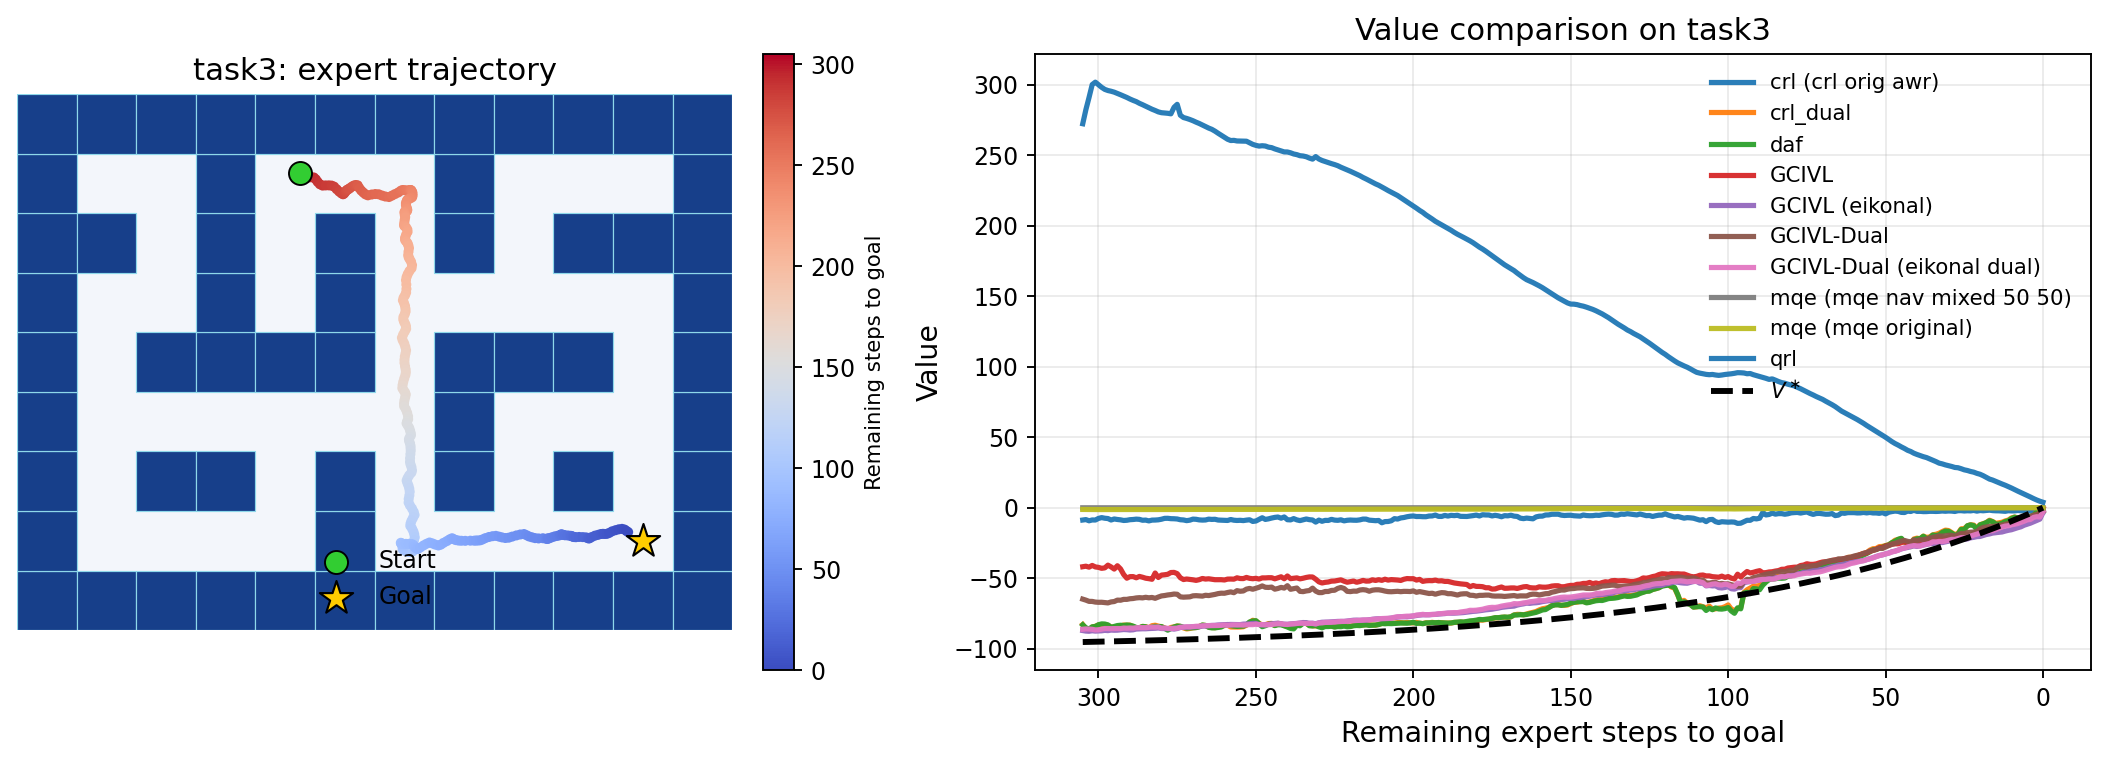

Could not plot ota on task4: Unsupported value extraction for ota


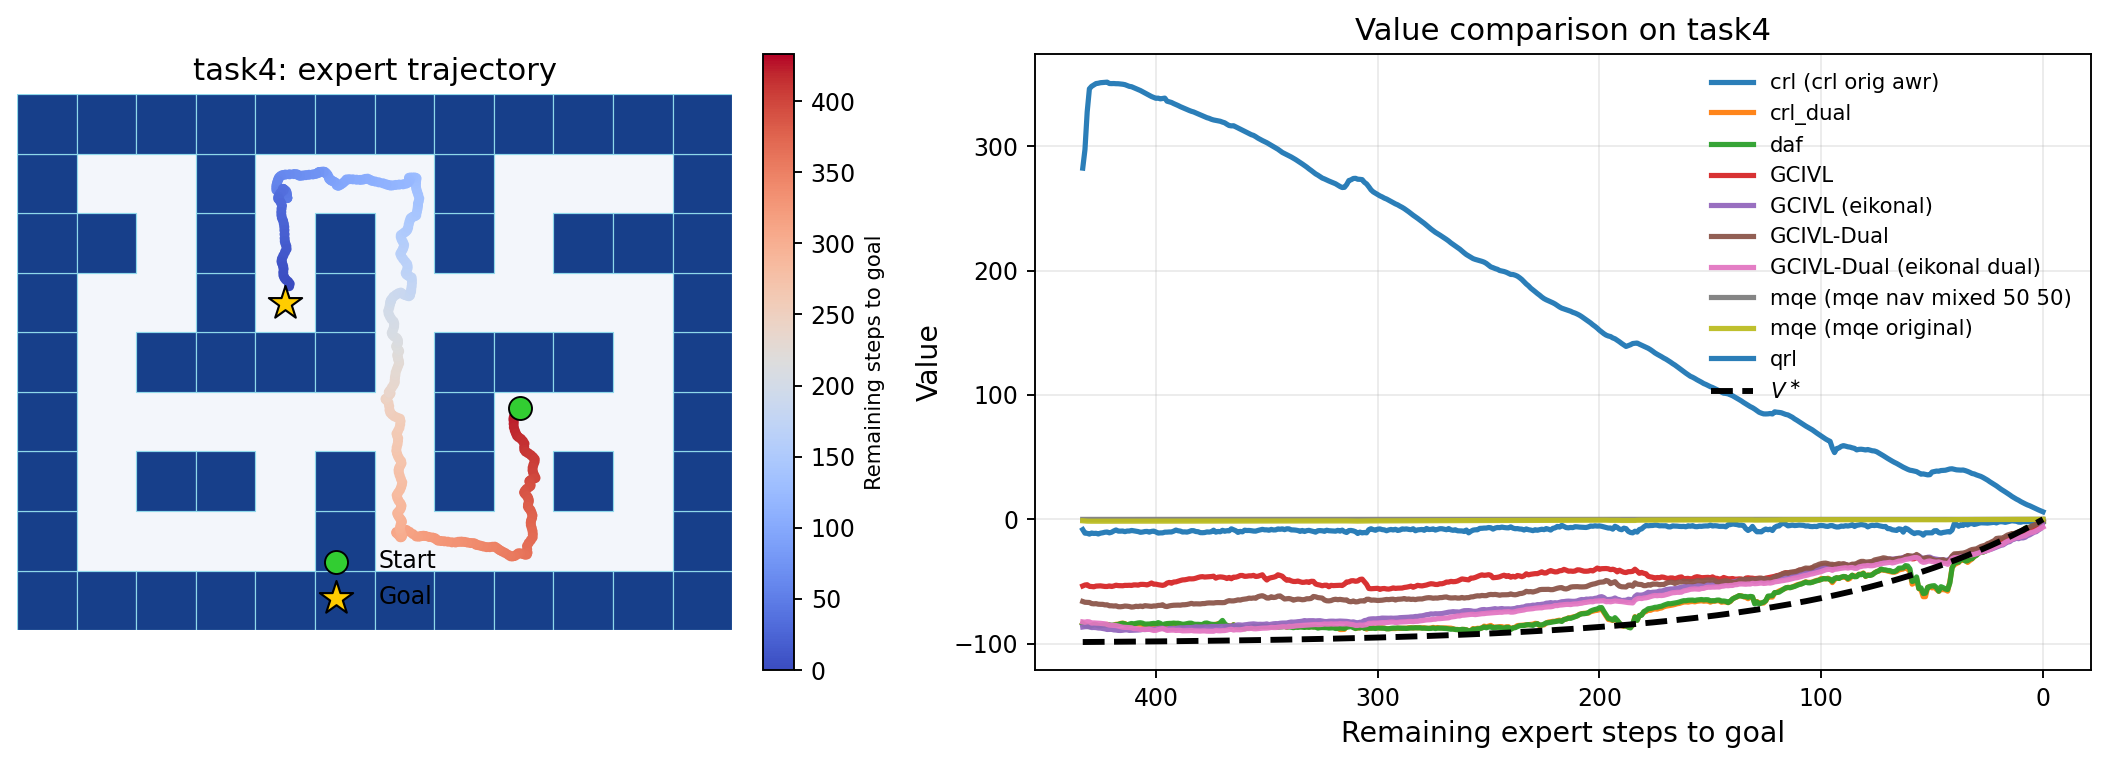

Could not plot ota on task5: Unsupported value extraction for ota


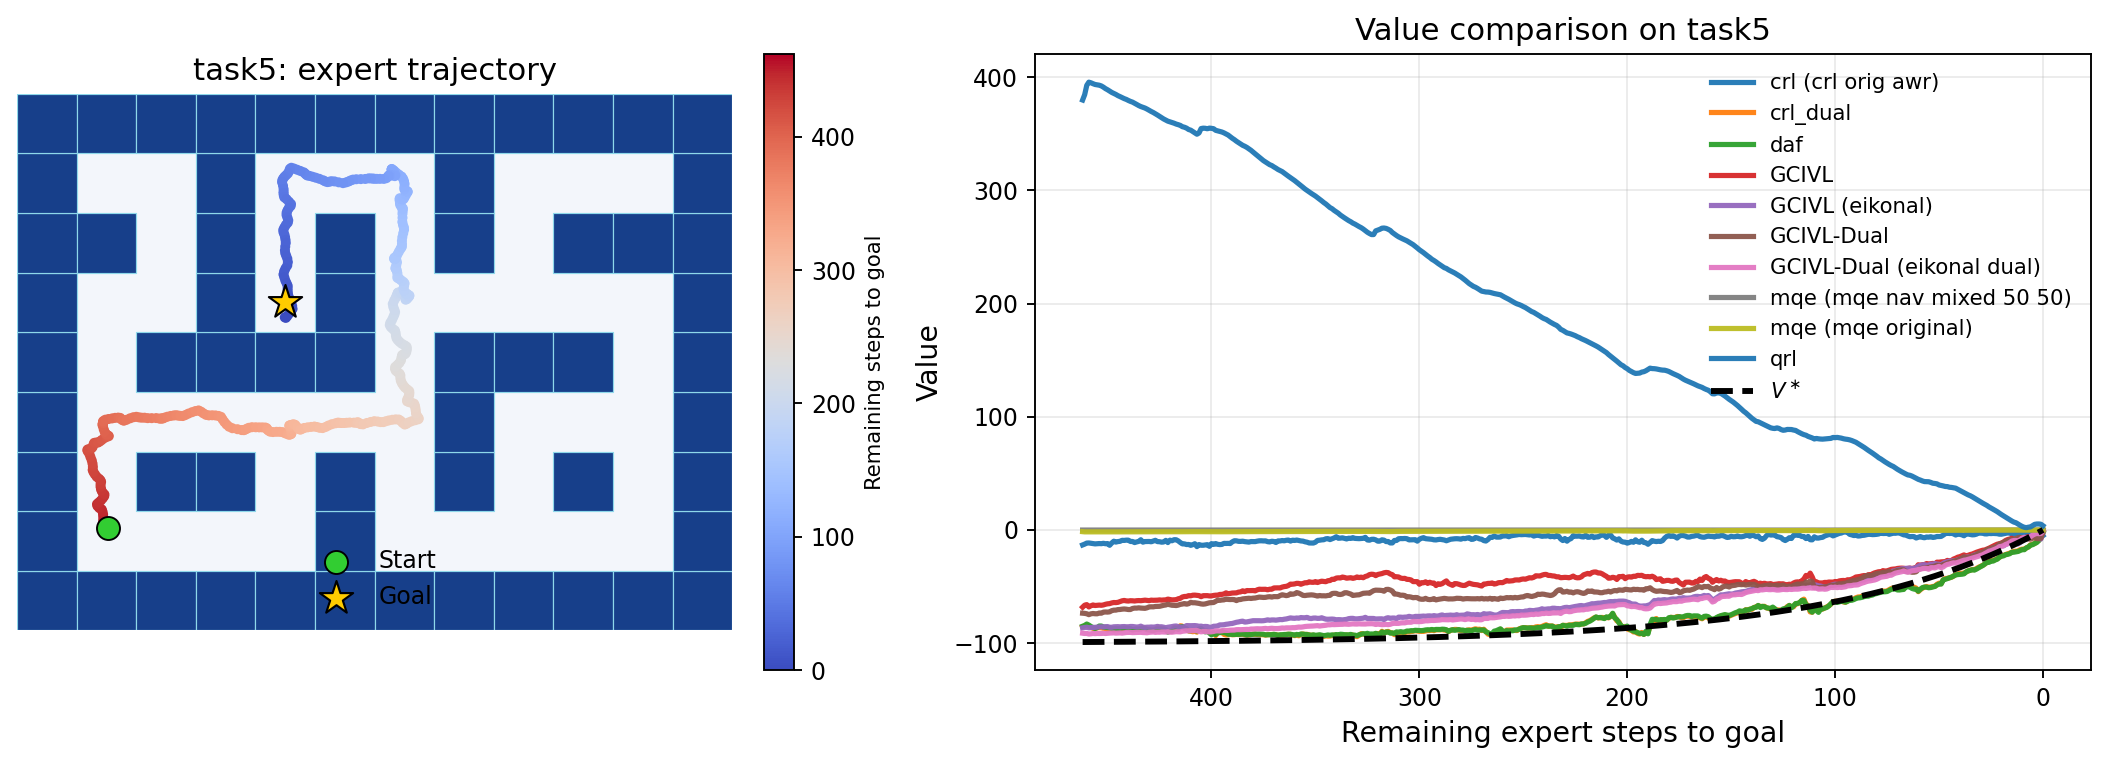

['plots/expert_value_profiles_compare/task1_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task2_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task3_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task4_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task5_all_agents_value_profile.png']

In [5]:
import os
import re
import json
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import jax
import jax.numpy as jnp
import ml_collections
import ogbench
from agents import agents as agent_registry
from utils.datasets import Dataset, GCDataset, HGCDataset, VIPDataset
from utils.flax_utils import restore_agent
from scipy.stats import spearmanr
from utils.antmaze_contours import (
    _build_antmaze_grid_and_analytic,
    _compute_learned_value_grid,
)

%matplotlib inline


def rank_corr(v_learned, v_star):
    """Spearman rank correlation between learned and optimal value profiles."""
    rho, _ = spearmanr(v_learned, v_star)
    return rho


def plot_all_found_agents_on_expert_trajectories(
    results_dir="../results",
    notebooks_dir="../notebooks",
    env_name="antmaze-large-navigate-v0",
    maze_type="large",
    save_dir="plots/expert_value_profiles_compare",
    show_inline=True,
    checkpoint_step=None,  # None -> latest
):
    os.makedirs(save_dir, exist_ok=True)
    # ------------------------------------------------------------
    # Build env + raw dataset once
    # ------------------------------------------------------------
    env, train_dataset_raw, _ = ogbench.make_env_and_datasets(dataset_name=env_name)
    dataset_class_map = {
        "GCDataset": GCDataset,
        "HGCDataset": HGCDataset,
        "VIPDataset": VIPDataset,
    }

    def make_example_batch(agent_cfg):
        dataset_class = dataset_class_map[agent_cfg["dataset_class"]]
        wrapped_dataset = dataset_class(
            Dataset.create(norm=agent_cfg["norm"], **train_dataset_raw),
            agent_cfg,
        )
        return wrapped_dataset.sample(1)

    # ------------------------------------------------------------
    # Build maze geometry once
    # ------------------------------------------------------------
    (
        X,
        Y,
        x_grid,
        y_grid,
        hx,
        hy,
        obstacle_mask,
        rects,
        v_eik_plot,
        v_fk_plot,
        v_eik_lines,
        v_fk_lines,
        policy_eik_x,
        policy_eik_y,
        policy_fk_x,
        policy_fk_y,
        goal_xy_eval,
        (x_min, x_max, y_min, y_max),
    ) = _build_antmaze_grid_and_analytic(
        maze_type=maze_type,
        points_per_cell=14,
        eikonal_cost_mode="unit",
    )

    # ------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------
    def pretty_label(run_dir_name, agent_name):
        suffix = re.sub(
            rf"^{re.escape(env_name)}_{re.escape(agent_name)}_sd\d{{3}}_?",
            "",
            run_dir_name,
        )
        base = {
            "gcivl": "GCIVL",
            "gcivl_dual": "GCIVL-Dual",
            "hilp": "HILP",
        }.get(agent_name, agent_name)
        if suffix == "":
            return base
        suffix = suffix.replace("_", " + ").replace("-", " ")
        return f"{base} ({suffix})"

    def load_run(run_dir):
        flags_path = os.path.join(run_dir, "flags.json")
        ckpt_dir = os.path.join(run_dir, "checkpoints")
        if not os.path.exists(flags_path) or not os.path.exists(ckpt_dir):
            return None
        with open(flags_path, "r") as f:
            flags_data = json.load(f)
        agent_cfg = flags_data["agent"]
        agent_name = agent_cfg["agent_name"]
        if agent_name not in agent_registry:
            print(f"Skipping {run_dir}: unknown agent '{agent_name}'")
            return None
        example_batch = make_example_batch(agent_cfg)
        agent_cls = agent_registry[agent_name]
        ex_goals = (
            example_batch["value_goals"] if agent_cfg.get("oraclerep", False) else None
        )
        agent = agent_cls.create(
            flags_data["seed"],
            example_batch["observations"],
            example_batch["actions"],
            ml_collections.ConfigDict(agent_cfg),
            ex_goals=ex_goals,
        )
        agent = restore_agent(agent, ckpt_dir, step=checkpoint_step)
        agent = jax.device_put(agent, device=jax.devices("cpu")[0])
        return {
            "label": pretty_label(os.path.basename(run_dir), agent_name),
            "run_dir": run_dir,
            "agent_name": agent_name,
            "discount": float(agent_cfg["discount"]),
            "agent": agent,
            "config": agent_cfg,
        }

    def compute_hilp_value(agent, observations, goal_observations):
        phis = agent.network.select("obs_repr")(observations)
        goal_phis = agent.network.select("obs_repr")(goal_observations)
        # HILP uses ensemble obs_repr with shape (E, B, D)
        if phis.ndim == 3:
            neg_dists = -jnp.sqrt(
                jnp.maximum(jnp.sum((phis - goal_phis) ** 2, axis=-1), 1e-6)
            )
            agg = agent.config["repr_agg"]
            if agg == "mean":
                values = jnp.mean(neg_dists, axis=0)
            else:
                values = jnp.min(neg_dists, axis=0)
        else:
            values = -jnp.sqrt(
                jnp.maximum(jnp.sum((phis - goal_phis) ** 2, axis=-1), 1e-6)
            )
        return np.asarray(values, dtype=np.float32)

    def compute_agent_value_profile(agent_bundle, observations, goal_observation):
        agent = agent_bundle["agent"]
        obs = jnp.asarray(observations, dtype=jnp.float32)
        goals = jnp.repeat(
            jnp.asarray(goal_observation[None, :], dtype=jnp.float32),
            repeats=observations.shape[0],
            axis=0,
        )
        modules = agent.network.model_def.modules

        # --- MQE: uses phi/psi modules with quasimetric distance ---
        if "phi" in modules and "psi" in modules:
            psi_s = agent.network.select("psi")(obs)
            psi_g = agent.network.select("psi")(goals)
            # psi may return ensemble shape (E, B, D)
            # if psi_s.ndim == 3:
            #     dists = agent.mrn_distance(psi_s, psi_g)          # (E, B)
            #     values = -(1.0 - jnp.power(0.99, dists)) / (1.0 - 0.99)
            #     # values = -jnp.mean(dists, axis=0)                  # (B,)
            # else:
            dist = agent.mrn_distance(psi_s, psi_g)  # * jnp.sqrt(psi_s.shape[-1])
            values = -(1.0 - jnp.power(0.995, dist)) / (1.0 - 0.995)
            return np.asarray(values.mean(0), dtype=np.float32)

        # --- HILP: uses obs_repr ---
        if "obs_repr" in modules:
            return compute_hilp_value(agent, obs, goals)

        # --- CRL / GCIVL / etc.: uses value or rep_value ---
        if "value" in modules or "rep_value" in modules:
            values = _compute_learned_value_grid(agent, obs, goals)
            return np.asarray(values, dtype=np.float32)

        raise ValueError(f"Unsupported value extraction for {agent_bundle['label']}")

    def optimal_v_from_remaining_steps(h, gamma):
        h = np.asarray(h, dtype=np.float32)
        if np.isclose(gamma, 1.0):
            return -h
        return -(1.0 - np.power(gamma, h)) / (1.0 - gamma)

    def parse_task_idx(path):
        m = re.search(r"task(\d+)\.npz$", os.path.basename(path))
        if m is None:
            return None
        return int(m.group(1)) - 1

    # ------------------------------------------------------------
    # Scan and load runs
    # ------------------------------------------------------------
    run_dirs = sorted(
        {
            str(Path(p).parent)
            for p in glob.glob(
                os.path.join(results_dir, "*", f"{env_name}_*", "flags.json")
            )
        }
    )
    loaded_agents = []
    for run_dir in run_dirs:
        try:
            bundle = load_run(run_dir)
            if bundle is not None:
                loaded_agents.append(bundle)
        except Exception as e:
            print(f"Skipping {run_dir}: {e}")
    if not loaded_agents:
        raise ValueError("No compatible runs found in results folder.")
    print("Loaded runs:")
    for bundle in loaded_agents:
        print(f" - {bundle['label']}")
    # ------------------------------------------------------------
    # Collect trajectories
    # ------------------------------------------------------------
    npz_paths = sorted(glob.glob(os.path.join(notebooks_dir, "*.npz")))
    npz_paths = [p for p in npz_paths if parse_task_idx(p) is not None]
    task_infos = env.unwrapped.task_infos
    # Stable colors
    cmap = plt.get_cmap("tab10")
    colors = {bundle["label"]: cmap(i % 10) for i, bundle in enumerate(loaded_agents)}
    saved_paths = []
    for traj_path in npz_paths:
        task_idx = parse_task_idx(traj_path)
        if task_idx is None or task_idx >= len(task_infos):
            continue
        task_info = task_infos[task_idx]
        task_name = task_info["task_name"]
        goal_xy = task_info["goal_xy"]
        traj = np.load(traj_path)
        expert_obs = traj["observations"].astype(np.float32)
        traj_xy = expert_obs[:, :2]
        goal_obs = expert_obs[-1].copy()
        goal_obs[0] = goal_xy[0]
        goal_obs[1] = goal_xy[1]
        T = expert_obs.shape[0]
        h_star = np.arange(T - 1, -1, -1, dtype=np.float32)
        # Use discount from first loaded agent for V*
        # (all current antmaze runs should share gamma=0.99)
        v_star = optimal_v_from_remaining_steps(h_star, loaded_agents[0]["discount"])
        fig, (ax_maze, ax_line) = plt.subplots(
            1,
            2,
            figsize=(12.5, 4.6),
            dpi=170,
            gridspec_kw={"width_ratios": [1.0, 1.35]},
        )
        # Left: same maze/expert trajectory for all approaches
        ax_maze.set_facecolor("#f3f6fb")
        for xmin, ymin, xmax, ymax in rects:
            ax_maze.add_patch(
                plt.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    facecolor="#173f8a",
                    edgecolor="#8ed8ea",
                    linewidth=0.5,
                    zorder=1,
                )
            )
        # ax_maze.plot(traj_xy[:, 0], traj_xy[:, 1], color="#d62728", lw=2.8, zorder=3)
        sc = ax_maze.scatter(
            traj_xy[:, 0],
            traj_xy[:, 1],
            c=h_star,  # color = remaining steps to goal
            cmap="coolwarm",
            s=18,
            zorder=3,
            edgecolors="none",
        )
        cbar = fig.colorbar(sc, ax=ax_maze, fraction=0.046, pad=0.04)
        cbar.set_label("Remaining steps to goal", fontsize=9)
        ax_maze.scatter(
            traj_xy[0, 0],
            traj_xy[0, 1],
            s=95,
            color="#32cd32",
            edgecolor="black",
            linewidth=0.8,
            zorder=4,
            label="Start",
        )
        ax_maze.scatter(
            goal_xy[0],
            goal_xy[1],
            marker="*",
            s=220,
            color="#ffcc00",
            edgecolor="black",
            linewidth=0.9,
            zorder=5,
            label="Goal",
        )
        ax_maze.set_xlim(x_min, x_max)
        ax_maze.set_ylim(y_min, y_max)
        ax_maze.set_aspect("equal")
        ax_maze.set_xticks([])
        ax_maze.set_yticks([])
        for spine in ax_maze.spines.values():
            spine.set_visible(False)
        ax_maze.set_title(f"{task_name}: expert trajectory", fontsize=13)
        ax_maze.legend(frameon=False, fontsize=10, loc="lower center")
        # Right: compare all agents
        for bundle in loaded_agents:
            try:
                v_learned = compute_agent_value_profile(bundle, expert_obs, goal_obs)
                # v_min, v_max = v_learned.min(), v_learned.max()
                # v_normed = (v_learned - v_min) / (v_max - v_min + 1e-8)
                # rho = rank_corr(v_normed, v_star)
                ax_line.plot(
                    h_star,
                    v_learned,  # v_normed
                    lw=2.2,
                    color=colors[bundle["label"]],
                    label=f"{bundle['label']}",  # (ρ={rho:.3f})",
                    alpha=0.95,
                )
            except Exception as e:
                print(f"Could not plot {bundle['label']} on {task_name}: {e}")
        # vs_min, vs_max = v_star.min(), v_star.max()
        # v_star_normed = (v_star - vs_min) / (vs_max - vs_min + 1e-8)
        ax_line.plot(h_star, v_star, "k--", lw=2.5, label=r"$V^\ast$")
        ax_line.set_xlabel("Remaining expert steps to goal", fontsize=12)
        ax_line.set_ylabel("Value", fontsize=12)
        ax_line.set_title(f"Value comparison on {task_name}", fontsize=13)
        ax_line.invert_xaxis()
        ax_line.grid(alpha=0.25)
        ax_line.legend(frameon=False, fontsize=9, loc="best")
        plt.tight_layout()
        save_path = os.path.join(save_dir, f"{task_name}_all_agents_value_profile.png")
        fig.savefig(save_path, bbox_inches="tight")
        saved_paths.append(save_path)
        if show_inline:
            display(fig)
        plt.close(fig)
    return {
        "loaded_agents": loaded_agents,
        "saved_paths": saved_paths,
    }


comparison = plot_all_found_agents_on_expert_trajectories(
    results_dir="../results",
    notebooks_dir="../notebooks",
    env_name="antmaze-large-navigate-v0",
    maze_type="large",
    save_dir="plots/expert_value_profiles_compare",
    show_inline=True,
    checkpoint_step=1_000_000,  # or None for latest
)
comparison["saved_paths"]

Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/crl/antmaze-large-navigate-v0_crl_sd000_crl-orig-awr/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/crl_dual/antmaze-large-navigate-v0_crl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/daf/antmaze-large-navigate-v0_daf_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gci

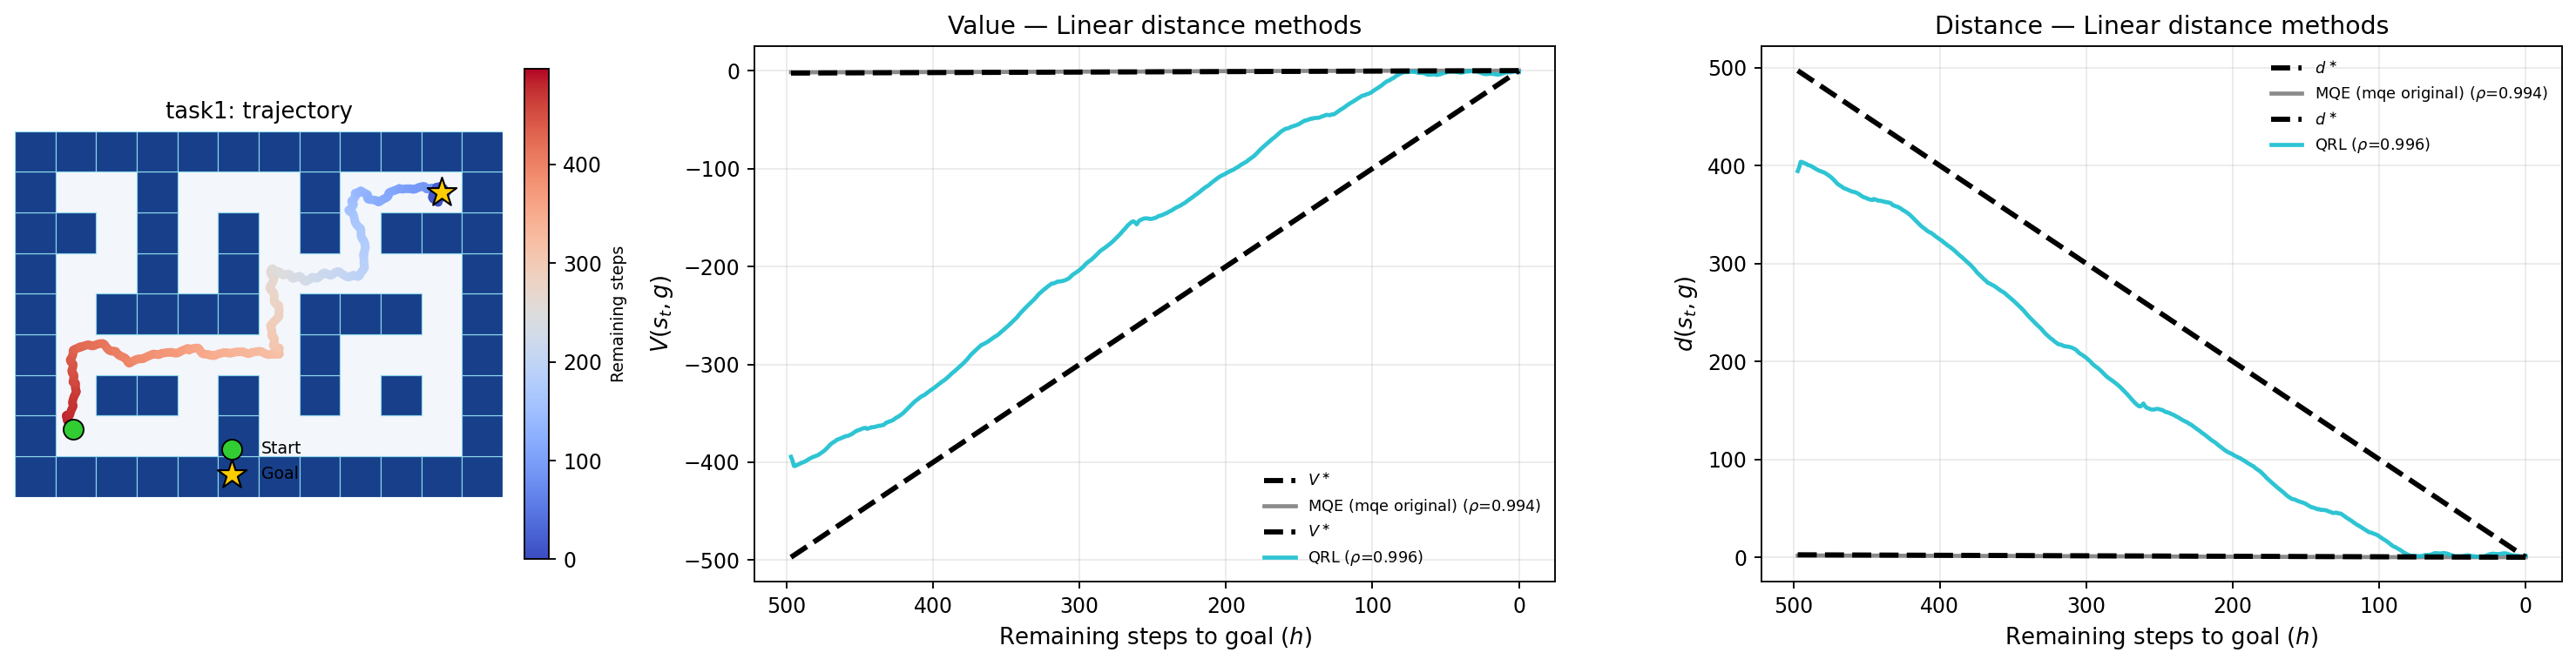

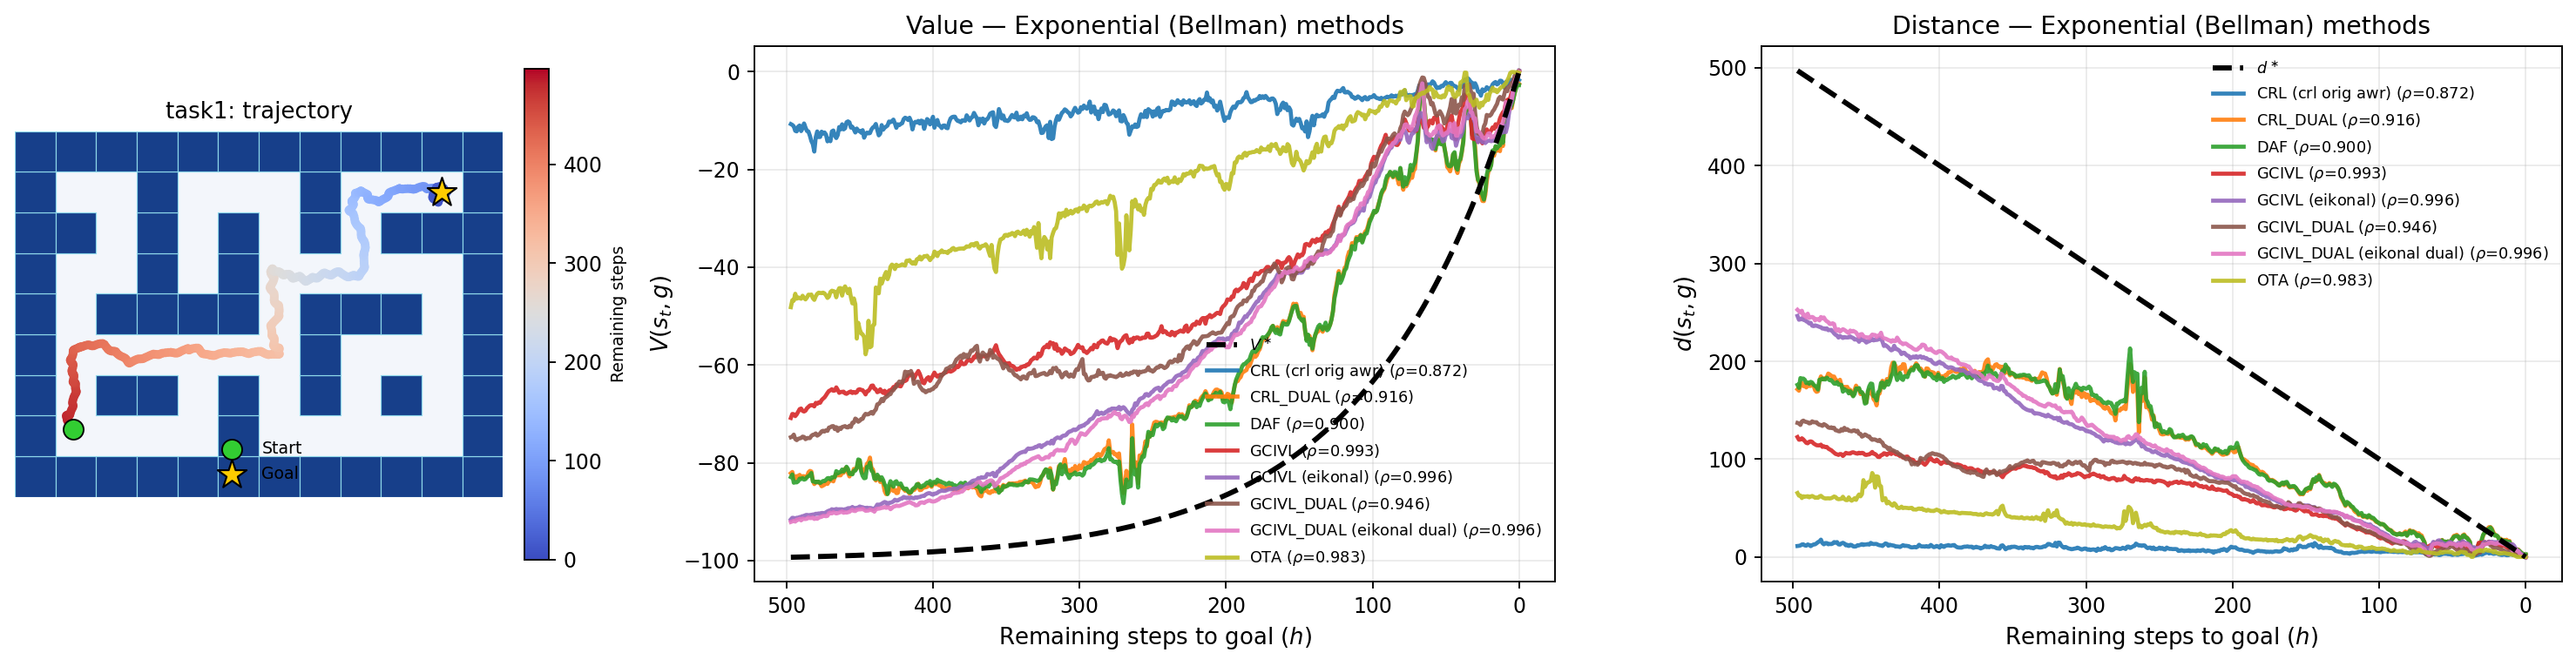

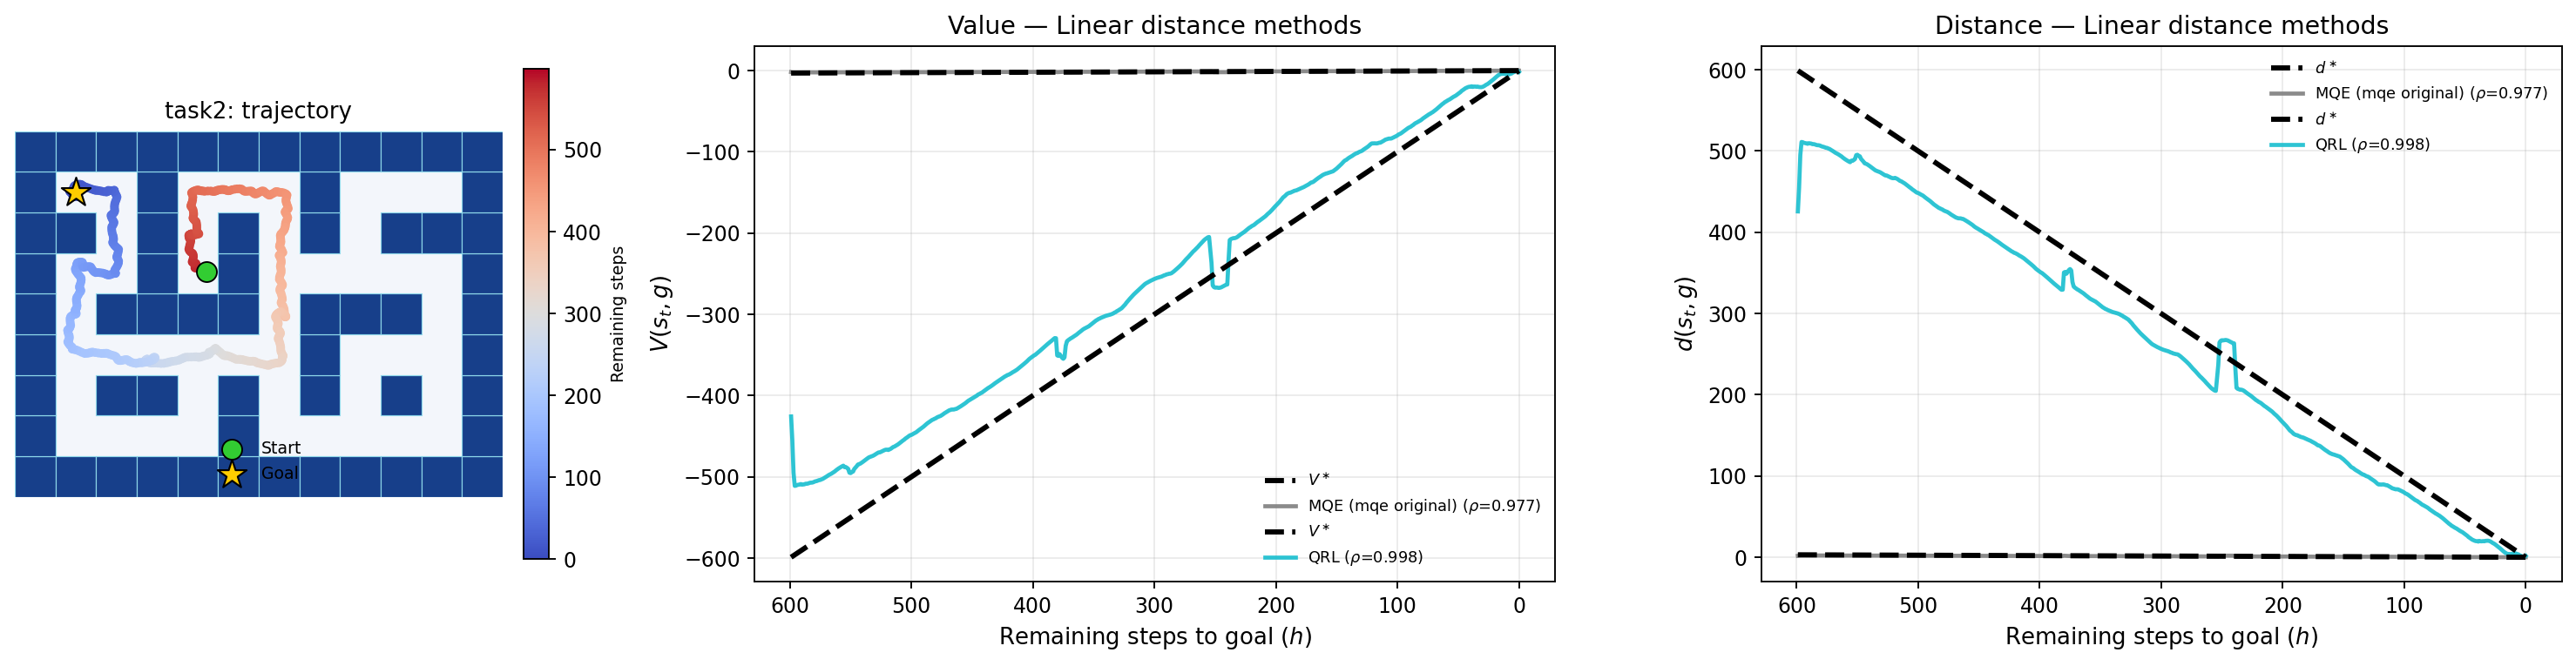

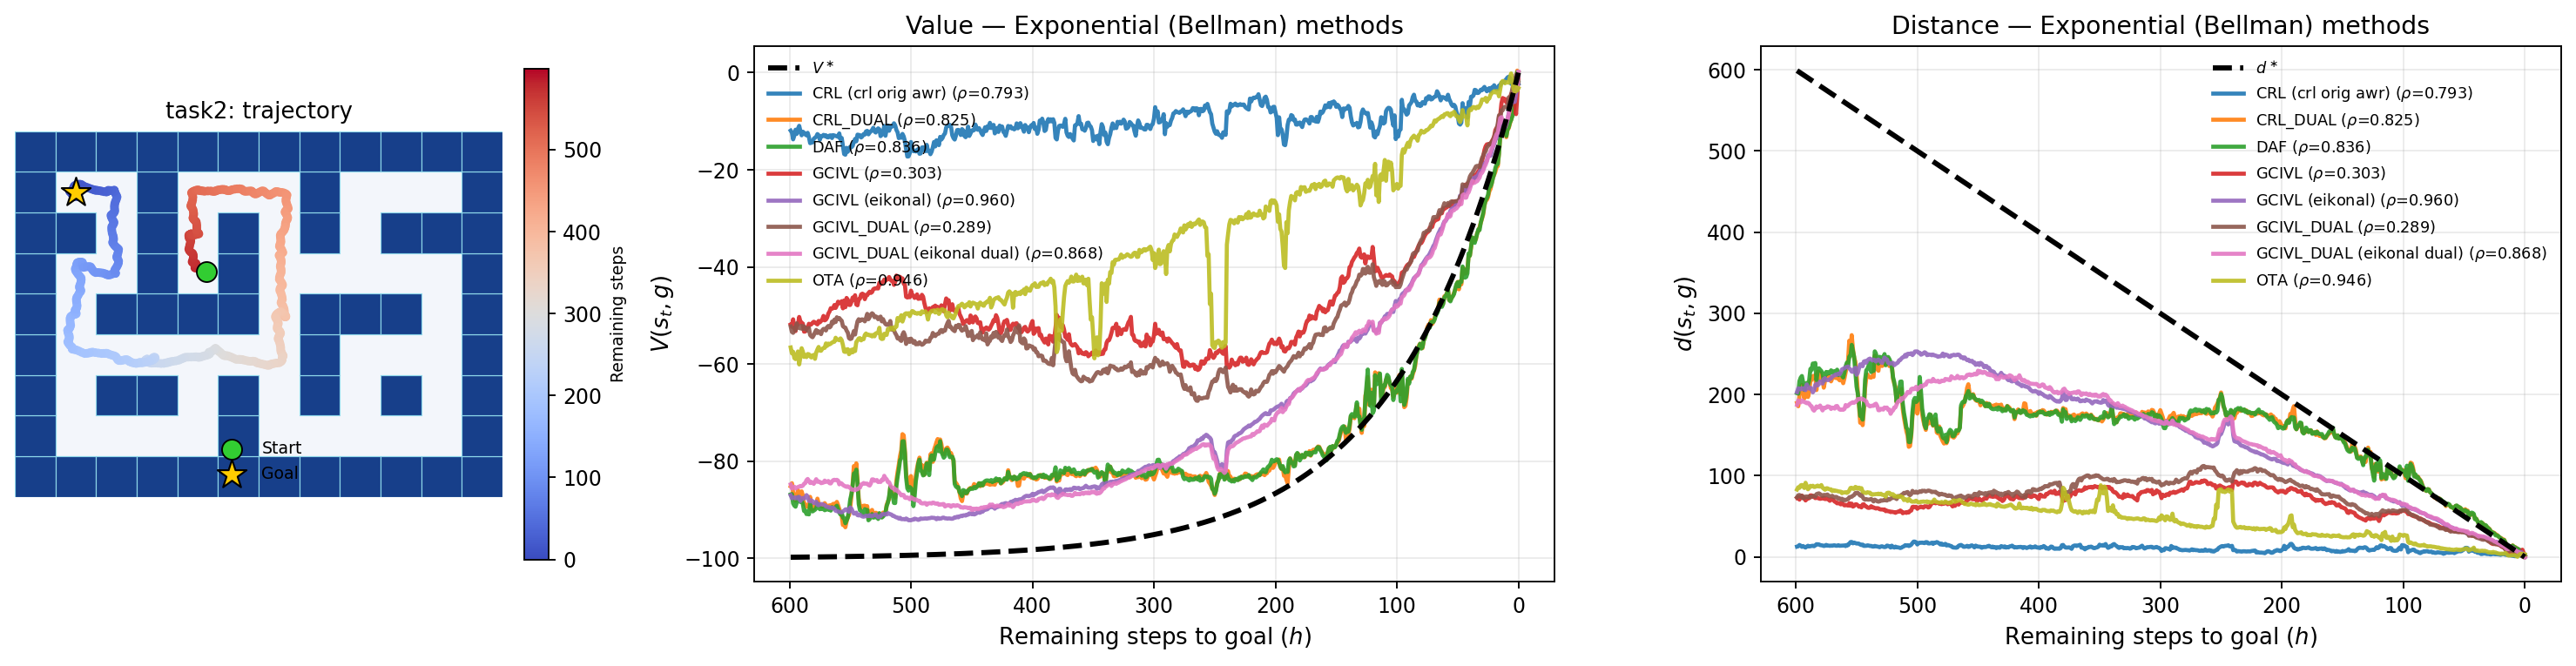

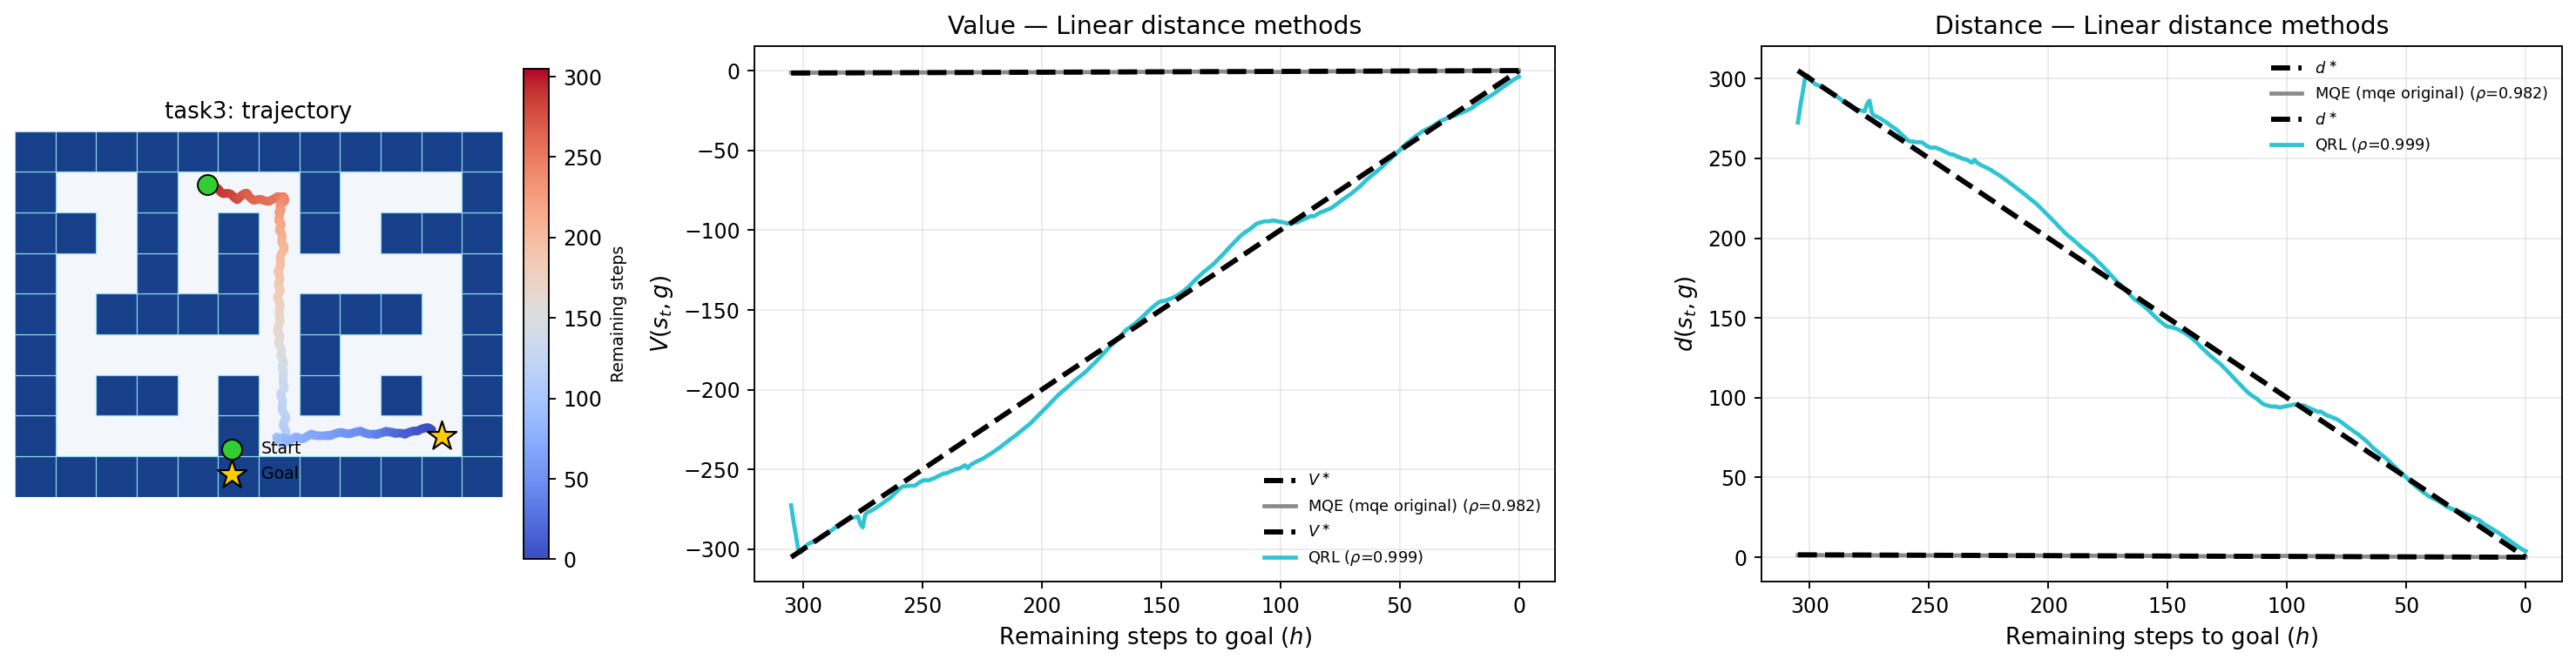

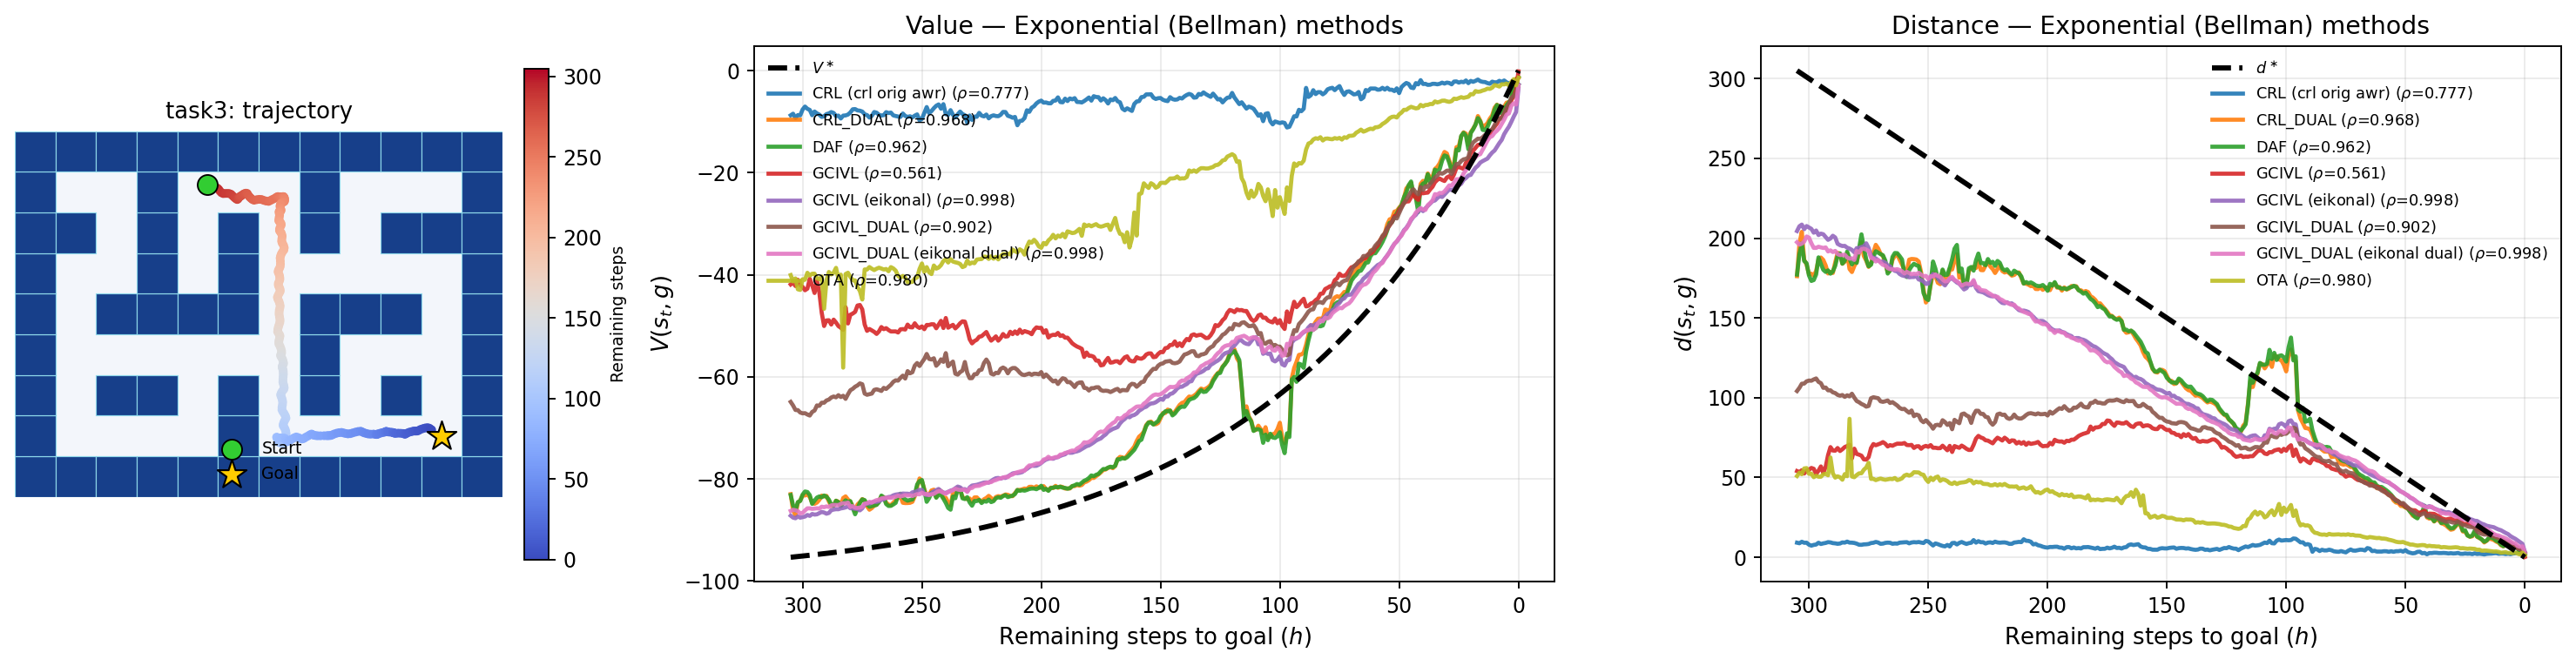

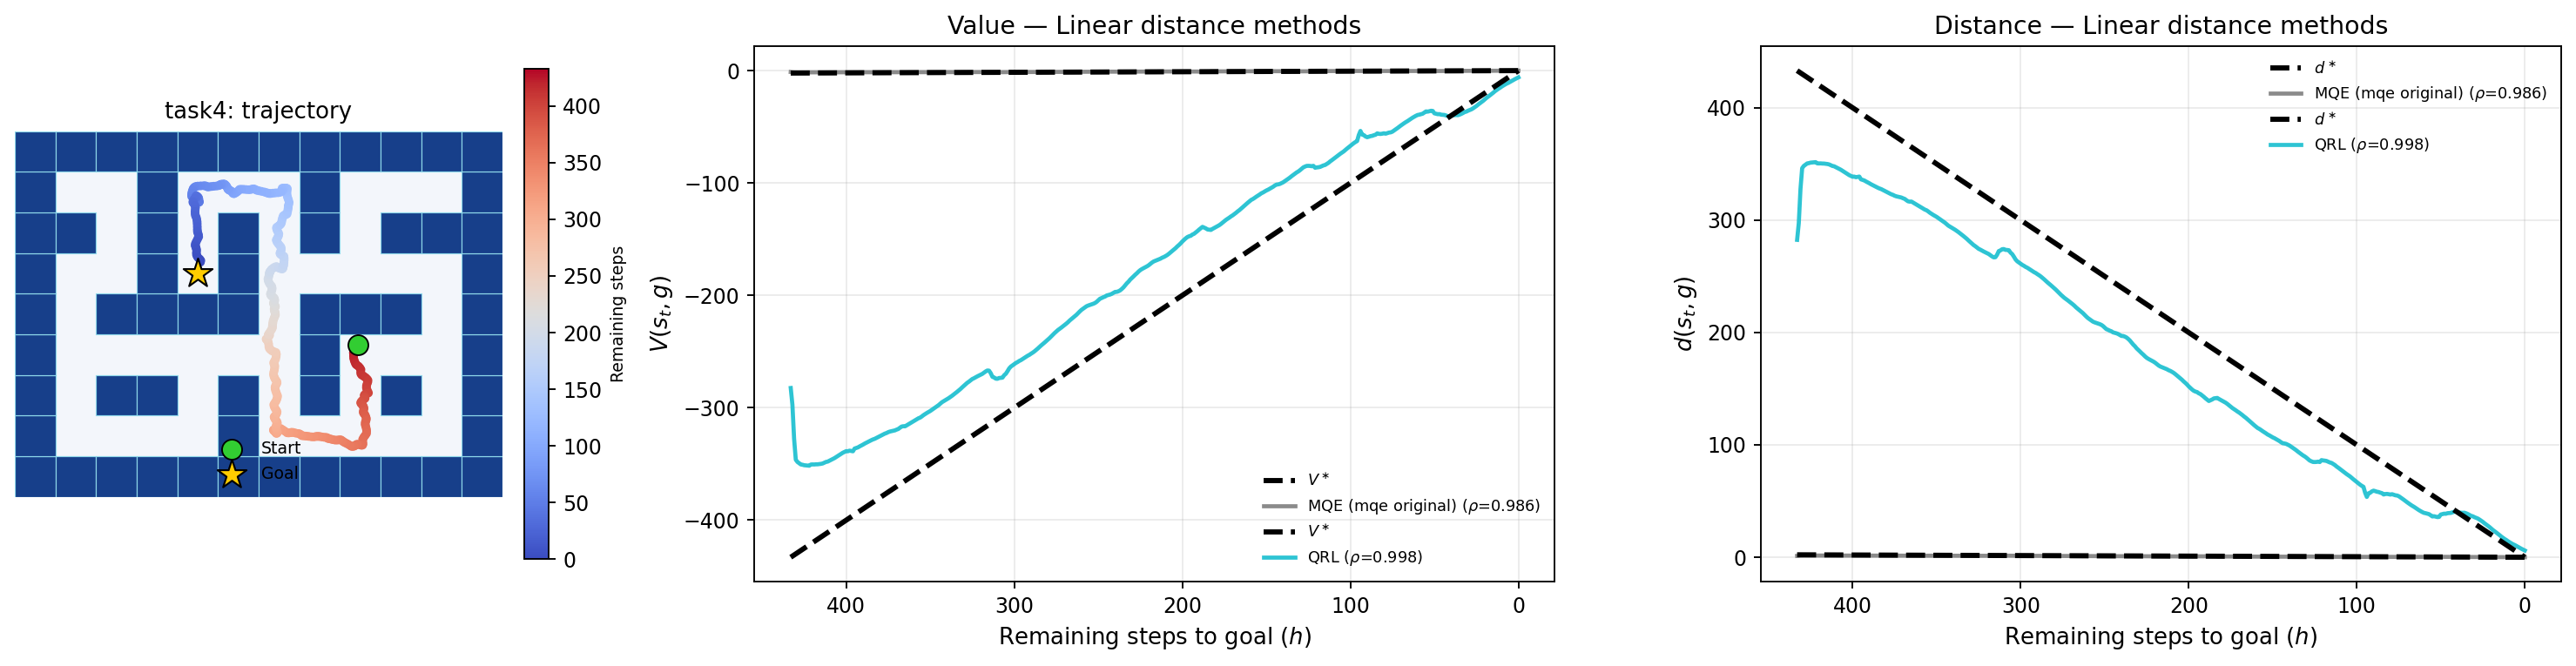

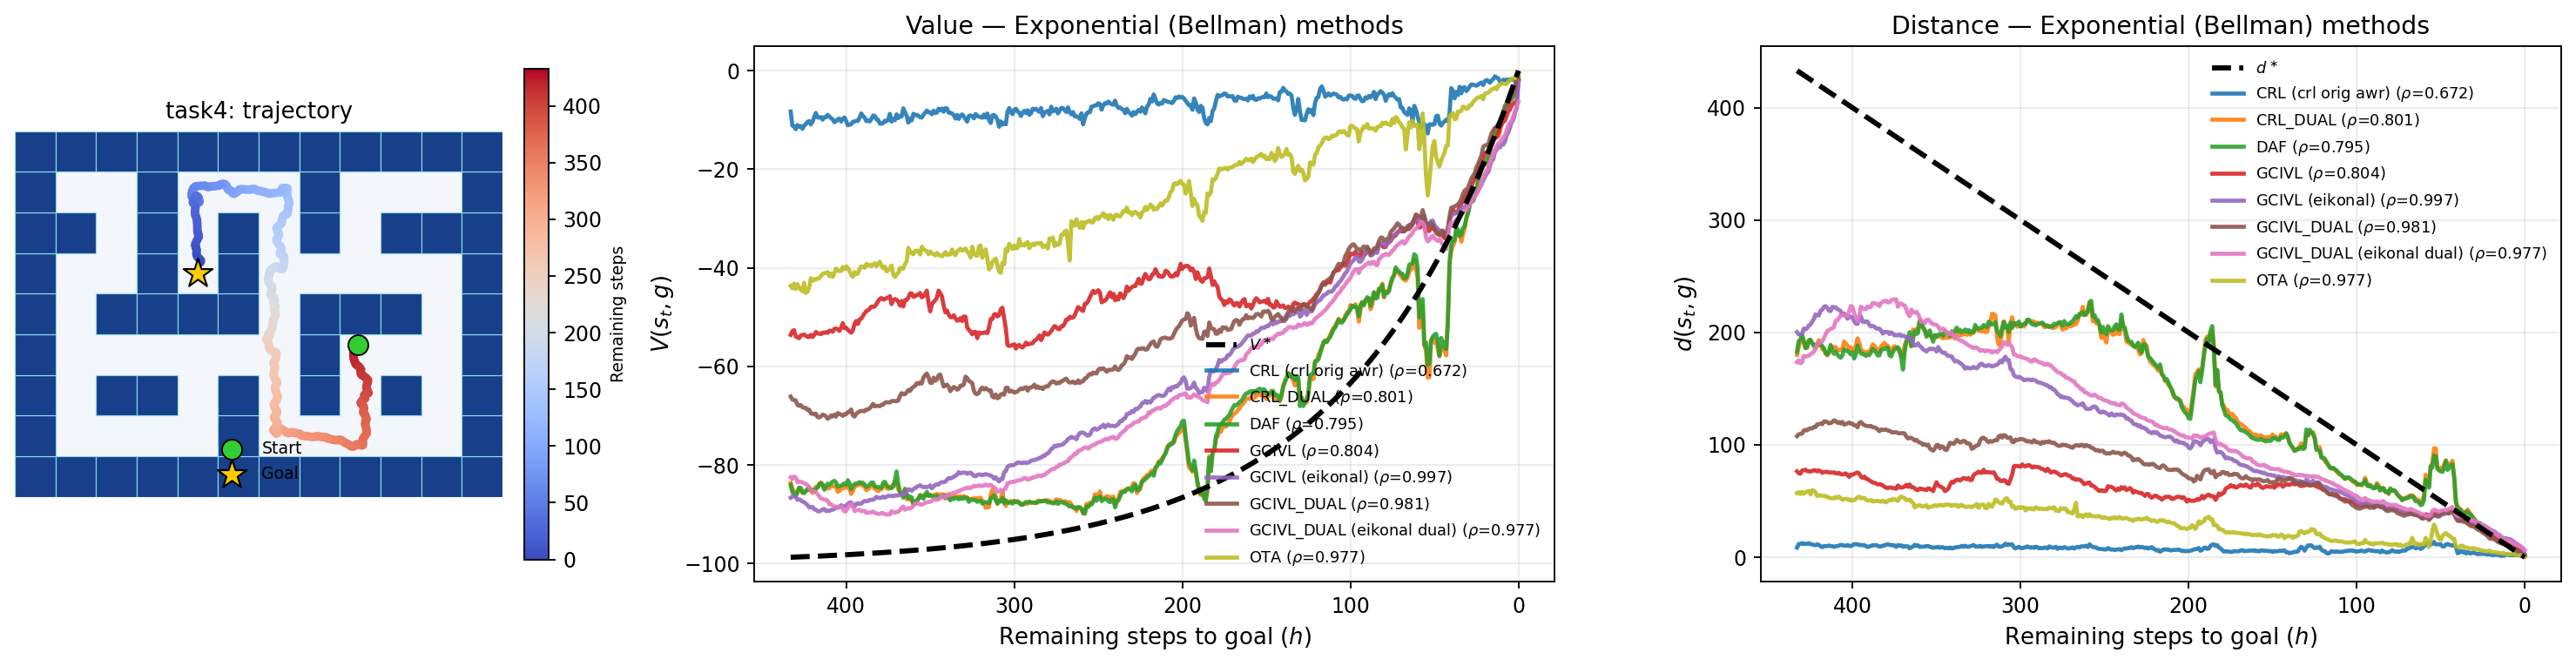

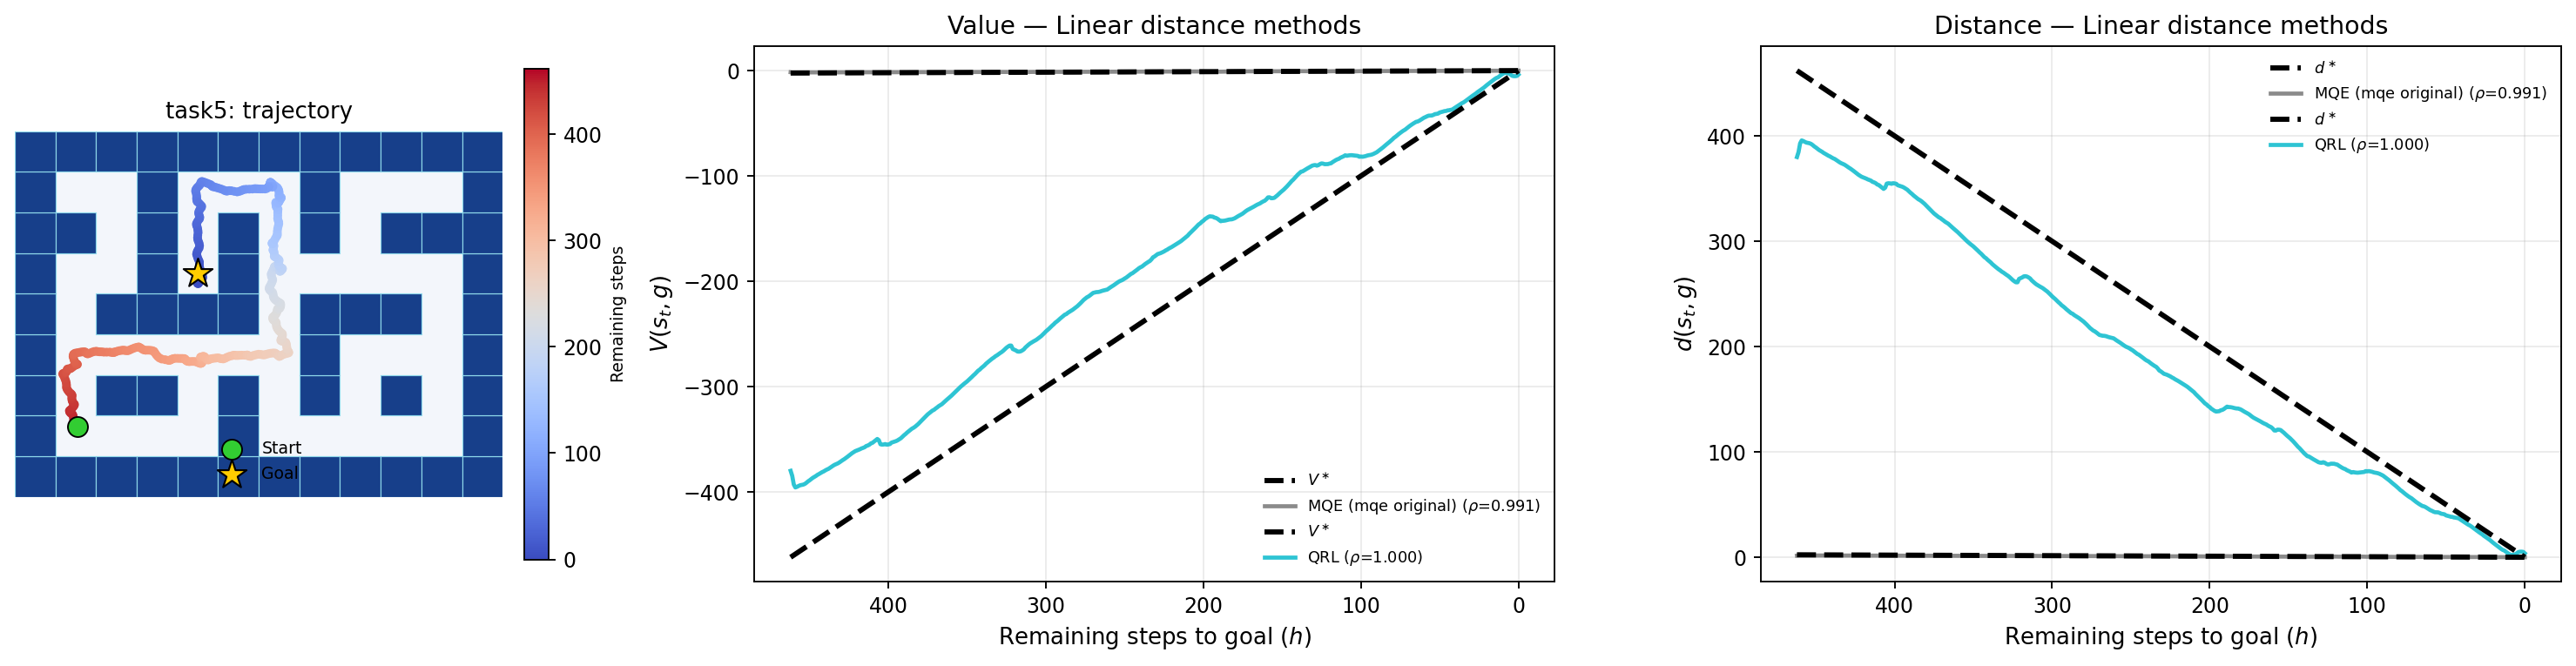

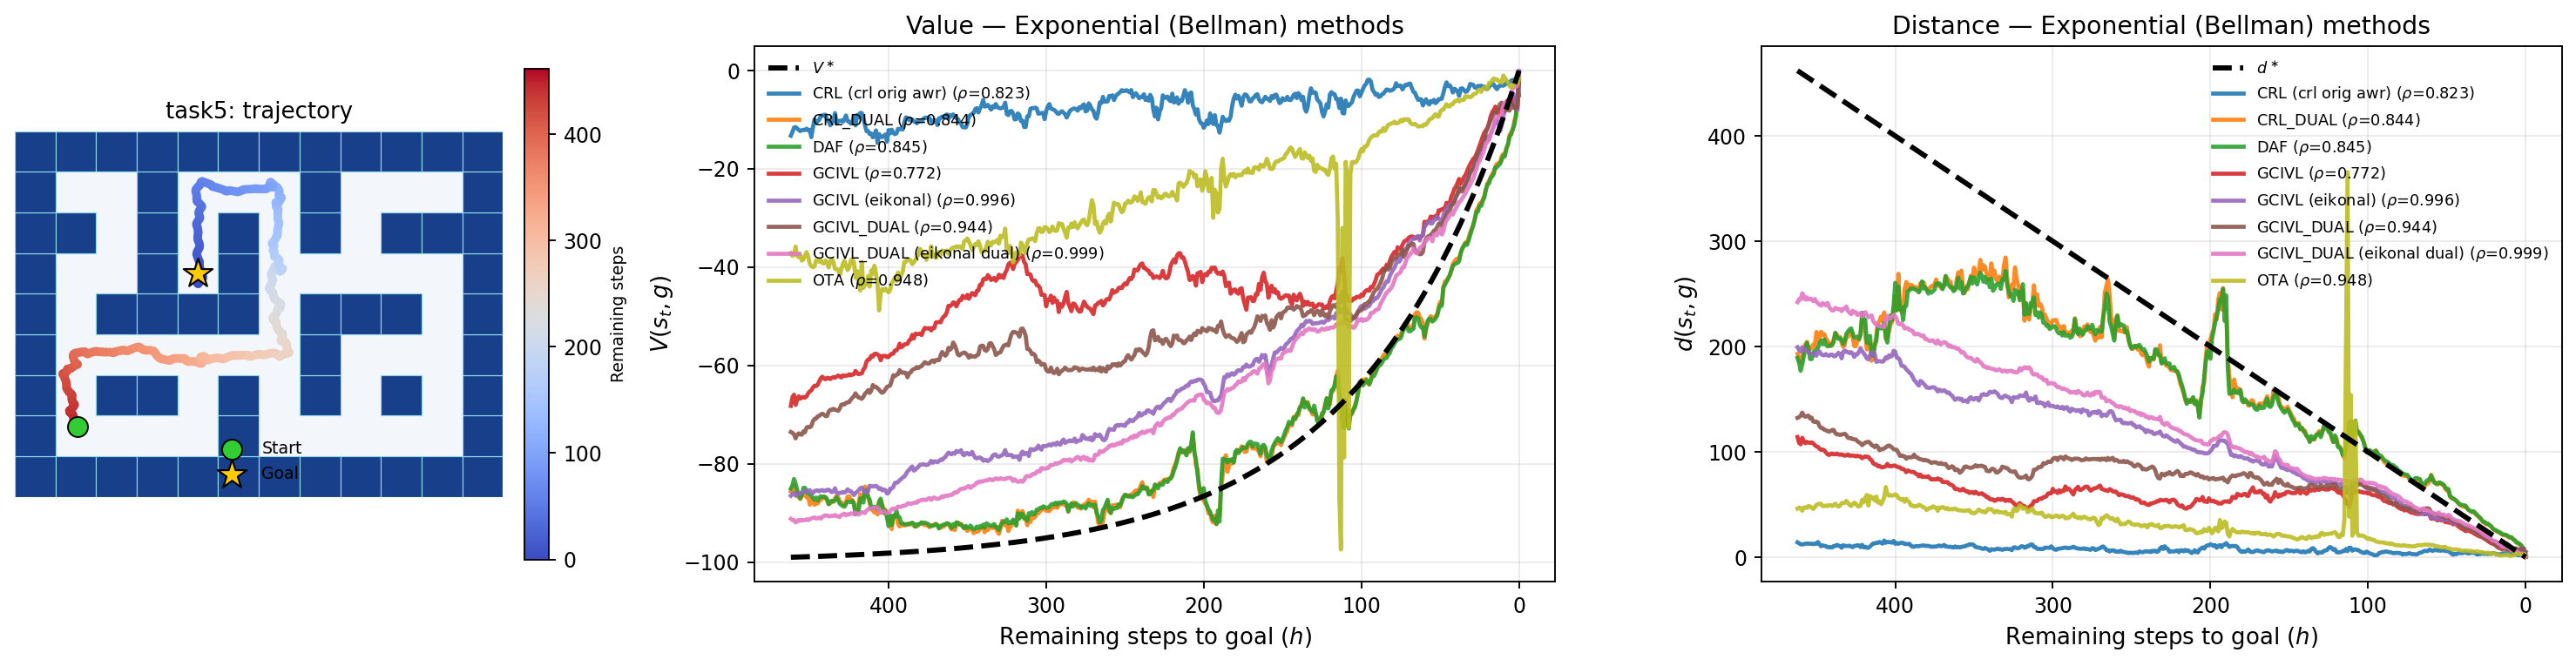

['plots/expert_value_profiles_compare/task1_linear_vd_profile.png',
 'plots/expert_value_profiles_compare/task1_exponential_vd_profile.png',
 'plots/expert_value_profiles_compare/task2_linear_vd_profile.png',
 'plots/expert_value_profiles_compare/task2_exponential_vd_profile.png',
 'plots/expert_value_profiles_compare/task3_linear_vd_profile.png',
 'plots/expert_value_profiles_compare/task3_exponential_vd_profile.png',
 'plots/expert_value_profiles_compare/task4_linear_vd_profile.png',
 'plots/expert_value_profiles_compare/task4_exponential_vd_profile.png',
 'plots/expert_value_profiles_compare/task5_linear_vd_profile.png',
 'plots/expert_value_profiles_compare/task5_exponential_vd_profile.png']

In [ ]:
import os
import re
import json
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import jax
import jax.numpy as jnp
import ml_collections
import ogbench
from agents import agents as agent_registry
from utils.datasets import Dataset, GCDataset, HGCDataset, VIPDataset
from utils.flax_utils import restore_agent
from scipy.stats import spearmanr
from utils.antmaze_contours import (
    _build_antmaze_grid_and_analytic,
    _compute_learned_value_grid,
)

%matplotlib inline


def rank_corr(a, b):
    rho, _ = spearmanr(a, b)
    return rho


# ── Ground-truth V* and d* ──────────────────────────────────────
def optimal_v_star(h, method_type, gamma=0.99):
    h = np.asarray(h, dtype=np.float64)
    if method_type == "qrl":
        return -h
    if method_type in ("mqe", "tmd"):
        return -h * np.log(1.0 / gamma)
    if np.isclose(gamma, 1.0):
        return -h
    return -(1.0 - np.power(gamma, h)) / (1.0 - gamma)


def optimal_d_star(h, method_type, gamma=0.99):
    h = np.asarray(h, dtype=np.float64)
    if method_type == "qrl":
        return h
    if method_type in ("mqe", "tmd"):
        return h * np.log(1.0 / gamma)
    return h


def v_to_d(v, method_type, gamma=0.99):
    """Convert learned V to temporal distance d.

    OTA paper: d^h = log(1 + (1-gamma)*V^h) / log(gamma)
    """
    v = np.asarray(v, dtype=np.float64)
    if method_type in ("qrl", "mqe", "tmd"):
        return -v
    inner = np.clip(1.0 + (1.0 - gamma) * v, 1e-12, None)
    return np.log(inner) / np.log(gamma)


# ── Helpers ──────────────────────────────────────────────────────
def parse_task_idx(path):
    m = re.search(r"task(\d+)\.npz$", os.path.basename(path))
    return int(m.group(1)) - 1 if m else None


def compute_agent_value_profile(agent_bundle, observations, goal_observation):
    agent = agent_bundle["agent"]
    config = agent_bundle["config"]
    obs = jnp.asarray(observations, dtype=jnp.float32)
    goals = jnp.repeat(
        jnp.asarray(goal_observation[None, :], dtype=jnp.float32),
        repeats=observations.shape[0],
        axis=0,
    )
    modules = agent.network.model_def.modules
    agent_name = config.get("agent_name", "")

    if agent_name == "qrl":
        d = agent.network.select("value")(obs, goals)
        return np.asarray(-d, dtype=np.float32), "qrl"
    if "phi" in modules and "psi" in modules:
        psi_s = agent.network.select("psi")(obs)
        psi_g = agent.network.select("psi")(goals)
        dist = agent.distance(psi_s, psi_g)
        values = -dist
        if values.ndim == 2:
            values = jnp.mean(values, axis=0)
        return np.asarray(values, dtype=np.float32), "mqe"
    if "high_value" in modules:
        v = agent.network.select("high_value")(obs, goals)
        if isinstance(v, tuple):
            v1, v2 = v
            v = jnp.minimum(v1, v2)
        elif v.ndim == 2 and v.shape[0] == 2:
            v = jnp.minimum(v[0], v[1])
        return np.asarray(v, dtype=np.float32), "bellman"
    if "value" in modules or "rep_value" in modules:
        values = _compute_learned_value_grid(agent, obs, goals)
        return np.asarray(values, dtype=np.float32), "bellman"
    raise ValueError(f"Unsupported value extraction for {agent_bundle['label']}")


def load_run(run_dir, env_name, make_example_batch_fn, checkpoint_step=None):
    flags_path = os.path.join(run_dir, "flags.json")
    ckpt_dir = os.path.join(run_dir, "checkpoints")
    if not os.path.exists(flags_path) or not os.path.exists(ckpt_dir):
        return None
    with open(flags_path, "r") as f:
        flags_data = json.load(f)
    agent_cfg = flags_data["agent"]
    agent_name = agent_cfg["agent_name"]
    if agent_name not in agent_registry:
        print(f"Skipping {run_dir}: unknown agent '{agent_name}'")
        return None
    if agent_name == "hilp":
        print(f"Skipping {run_dir}: HILP excluded")
        return None
    example_batch = make_example_batch_fn(agent_cfg)
    agent_cls = agent_registry[agent_name]
    ex_goals = (
        example_batch["value_goals"] if agent_cfg.get("oraclerep", False) else None
    )
    agent = agent_cls.create(
        flags_data["seed"],
        example_batch["observations"],
        example_batch["actions"],
        ml_collections.ConfigDict(agent_cfg),
        ex_goals=ex_goals,
    )
    agent = restore_agent(agent, ckpt_dir, step=checkpoint_step)
    agent = jax.device_put(agent, device=jax.devices("cpu")[0])
    dir_name = os.path.basename(run_dir)
    train_env = flags_data.get("env_name", env_name)
    suffix = re.sub(
        rf"^{re.escape(train_env)}_{re.escape(agent_name)}_sd\d{{3}}_?", "", dir_name
    )
    base = agent_name.upper()
    env_tag = ""
    if train_env != env_name:
        parts = train_env.replace(env_name.split("-")[0] + "maze-", "").split("-")
        env_tag = f"train={'-'.join(parts[:2])}"
    parts = [base]
    if suffix:
        parts.append(suffix.replace("_", "+").replace("-", " "))
    if env_tag:
        parts.append(env_tag)
    label = (
        " ".join(parts) if len(parts) == 1 else f"{parts[0]} ({', '.join(parts[1:])})"
    )
    return {
        "label": label,
        "run_dir": run_dir,
        "agent_name": agent_name,
        "discount": float(agent_cfg["discount"]),
        "agent": agent,
        "config": agent_cfg,
    }


LINEAR_METHODS = {"qrl", "mqe", "tmd"}


def _classify_method_type(mt):
    return "linear" if mt in LINEAR_METHODS else "exponential"


def _draw_maze(
    ax, traj_xy, h_star, goal_xy, rects, x_min, x_max, y_min, y_max, task_name, fig
):
    ax.set_facecolor("#f3f6fb")
    for xmin, ymin, xmax, ymax in rects:
        ax.add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                facecolor="#173f8a",
                edgecolor="#8ed8ea",
                linewidth=0.5,
                zorder=1,
            )
        )
    sc = ax.scatter(
        traj_xy[:, 0],
        traj_xy[:, 1],
        c=h_star,
        cmap="coolwarm",
        s=18,
        zorder=3,
        edgecolors="none",
    )
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label(
        "Remaining steps", fontsize=8
    )
    ax.scatter(
        traj_xy[0, 0],
        traj_xy[0, 1],
        s=95,
        color="#32cd32",
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
        label="Start",
    )
    ax.scatter(
        goal_xy[0],
        goal_xy[1],
        marker="*",
        s=220,
        color="#ffcc00",
        edgecolor="black",
        linewidth=0.9,
        zorder=5,
        label="Goal",
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"{task_name}: trajectory", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower center")


def plot_all_found_agents_on_expert_trajectories(
    results_dir="../results",
    notebooks_dir="../notebooks",
    env_name="antmaze-large-navigate-v0",
    maze_type="large",
    save_dir="plots/expert_value_profiles_compare",
    show_inline=True,
    checkpoint_step=None,
    extra_run_dirs=None,
):
    """OTA-style plots: V and d vs remaining steps h (raw scale, no normalization).

    1x3 figure per (task, distance_class):
      [maze]  [V(h): V* curve + learned V]  [d(h): d* line + learned d]
    V* is exponential for Bellman methods; d* is always linear (= h).
    Order inconsistency shows as non-monotonicity in the d panel.
    """
    os.makedirs(save_dir, exist_ok=True)
    extra_run_dirs = extra_run_dirs or []

    env, train_dataset_raw, _ = ogbench.make_env_and_datasets(dataset_name=env_name)
    dcmap = {"GCDataset": GCDataset, "HGCDataset": HGCDataset, "VIPDataset": VIPDataset}

    def make_eb(cfg):
        return dcmap[cfg["dataset_class"]](
            Dataset.create(norm=cfg["norm"], **train_dataset_raw), cfg
        ).sample(1)

    geo = _build_antmaze_grid_and_analytic(
        maze_type=maze_type, points_per_cell=14, eikonal_cost_mode="unit"
    )
    (
        X,
        Y,
        x_grid,
        y_grid,
        hx,
        hy,
        obstacle_mask,
        rects,
        v_eik_plot,
        v_fk_plot,
        v_eik_lines,
        v_fk_lines,
        policy_eik_x,
        policy_eik_y,
        policy_fk_x,
        policy_fk_y,
        goal_xy_eval,
        (x_min, x_max, y_min, y_max),
    ) = geo

    run_dirs = sorted(
        {
            str(Path(p).parent)
            for p in glob.glob(
                os.path.join(results_dir, "*", f"{env_name}_*", "flags.json")
            )
        }
    )
    for d in extra_run_dirs:
        if d not in run_dirs:
            run_dirs.append(d)

    loaded = []
    for rd in run_dirs:
        try:
            b = load_run(rd, env_name, make_eb, checkpoint_step)
            if b:
                loaded.append(b)
        except Exception as e:
            print(f"Skipping {rd}: {e}")
    if not loaded:
        raise ValueError("No runs found.")
    print("Loaded:")
    [print(f"  - {b['label']}") for b in loaded]

    cmap = plt.get_cmap("tab10")
    colors = {b["label"]: cmap(i % 10) for i, b in enumerate(loaded)}

    npz_paths = [
        p
        for p in sorted(glob.glob(os.path.join(notebooks_dir, "*.npz")))
        if parse_task_idx(p) is not None
    ]
    task_infos = env.unwrapped.task_infos

    saved = []
    for traj_path in npz_paths:
        tidx = parse_task_idx(traj_path)
        if tidx is None or tidx >= len(task_infos):
            continue
        ti = task_infos[tidx]
        task_name, goal_xy = ti["task_name"], ti["goal_xy"]

        traj = np.load(traj_path)
        expert_obs = traj["observations"].astype(np.float32)
        traj_xy = expert_obs[:, :2]
        goal_obs = expert_obs[-1].copy()
        goal_obs[0], goal_obs[1] = goal_xy[0], goal_xy[1]
        T = expert_obs.shape[0]
        h = np.arange(T - 1, -1, -1, dtype=np.float64)

        results = []
        for b in loaded:
            try:
                vl, mt = compute_agent_value_profile(b, expert_obs, goal_obs)
                results.append((b, vl, mt, _classify_method_type(mt)))
            except Exception as e:
                print(f"Could not compute {b['label']} on {task_name}: {e}")

        for dc, title in [
            ("linear", "Linear distance methods"),
            ("exponential", "Exponential (Bellman) methods"),
        ]:
            sub = [r for r in results if r[3] == dc]
            if not sub:
                continue

            fig, (ax_m, ax_v, ax_d) = plt.subplots(
                1,
                3,
                figsize=(17.5, 4.6),
                dpi=170,
                gridspec_kw={"width_ratios": [0.8, 1.2, 1.2]},
            )
            _draw_maze(
                ax_m,
                traj_xy,
                h,
                goal_xy,
                rects,
                x_min,
                x_max,
                y_min,
                y_max,
                task_name,
                fig,
            )

            v_star_drawn, d_star_drawn = set(), set()

            for bnd, vl_raw, mt, _ in sub:
                gamma = bnd["discount"]
                c = colors[bnd["label"]]

                # ── V panel: x = remaining steps h, y = value ──
                v_ref = optimal_v_star(h, mt, gamma)
                if mt not in v_star_drawn:
                    ax_v.plot(h, v_ref, "k--", lw=2.5, label=r"$V^\ast$", zorder=5)
                    v_star_drawn.add(mt)
                rho_v = rank_corr(vl_raw, v_ref)
                ax_v.plot(
                    h,
                    vl_raw,
                    lw=2.0,
                    color=c,
                    alpha=0.9,
                    label=f"{bnd['label']} ($\\rho$={rho_v:.3f})",
                )

                # ── d panel: x = remaining steps h, y = distance ──
                d_ref = optimal_d_star(h, mt, gamma)
                dl = v_to_d(vl_raw, mt, gamma)
                if mt not in d_star_drawn:
                    ax_d.plot(h, d_ref, "k--", lw=2.5, label=r"$d^\ast$", zorder=5)
                    d_star_drawn.add(mt)
                rho_d = rank_corr(dl, d_ref)
                ax_d.plot(
                    h,
                    dl,
                    lw=2.0,
                    color=c,
                    alpha=0.9,
                    label=f"{bnd['label']} ($\\rho$={rho_d:.3f})",
                )

            ax_v.set_xlabel("Remaining steps to goal ($h$)", fontsize=11)
            ax_v.set_ylabel("$V(s_t, g)$", fontsize=11)
            ax_v.set_title(f"Value — {title}", fontsize=12)
            ax_v.invert_xaxis()
            ax_v.grid(alpha=0.25)
            ax_v.legend(frameon=False, fontsize=7.5, loc="best")

            ax_d.set_xlabel("Remaining steps to goal ($h$)", fontsize=11)
            ax_d.set_ylabel("$d(s_t, g)$", fontsize=11)
            ax_d.set_title(f"Distance — {title}", fontsize=12)
            ax_d.invert_xaxis()
            ax_d.grid(alpha=0.25)
            ax_d.legend(frameon=False, fontsize=7.5, loc="best")

            plt.tight_layout()
            sp = os.path.join(save_dir, f"{task_name}_{dc}_vd_profile.png")
            fig.savefig(sp, bbox_inches="tight")
            saved.append(sp)
            if show_inline:
                display(fig)
            plt.close(fig)

    return {"loaded_agents": loaded, "saved_paths": saved}


comparison = plot_all_found_agents_on_expert_trajectories(
    results_dir="../results",
    notebooks_dir="../notebooks",
    env_name="antmaze-large-navigate-v0",
    maze_type="large",
    save_dir="plots/expert_value_profiles_compare",
    show_inline=True,
    checkpoint_step=1_000_000,
    extra_run_dirs=[
        "/home/m_bobrin/dual-goal-representations/results/qrl/antmaze-large-explore-v0_qrl_sd000",
    ],
)
comparison["saved_paths"]